 #### Анализ данных

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
# Загрузка данных
data = pd.read_excel('data.xlsx')

In [58]:
data.shape

(1001, 214)

In [59]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Columns: 214 entries, Unnamed: 0 to fr_urea
dtypes: float64(107), int64(107)
memory usage: 1.6 MB


In [60]:
data

,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,...,0,0,0,0,0,0,0,0,3,0
1,1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,...,0,0,0,0,0,0,0,0,3,0
2,2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,...,0,0,0,0,0,0,0,0,3,0
3,3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,...,0,0,0,0,0,0,0,0,4,0
4,4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,996,31.000104,34.999650,1.129017,12.934891,12.934891,0.048029,-0.476142,0.382752,49.133333,...,0,0,0,0,0,0,0,0,0,0
997,997,31.999934,33.999415,1.062484,13.635345,13.635345,0.030329,-0.699355,0.369425,44.542857,...,0,0,0,0,0,0,0,0,0,0
998,998,30.999883,33.999458,1.096761,13.991690,13.991690,0.026535,-0.650790,0.284923,41.973684,...,1,0,0,0,0,0,0,0,0,0
999,999,31.998959,32.999644,1.031272,13.830180,13.830180,0.146522,-1.408652,0.381559,39.000000,...,0,0,0,0,0,0,0,0,0,0


In [61]:
 # Названия признаков
cols = list(data.columns)
for i in range(0, len(cols), 10):
    print(cols[i:i+10])

['Unnamed: 0', 'IC50, mM', 'CC50, mM', 'SI', 'MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS']
['MolWt', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'NumRadicalElectrons', 'MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge', 'FpDensityMorgan1']
['FpDensityMorgan2', 'FpDensityMorgan3', 'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO', 'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI', 'BCUT2D_MRLOW']
['AvgIpc', 'BalabanJ', 'BertzCT', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n']
['Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'HallKierAlpha', 'Ipc', 'Kappa1', 'Kappa2', 'Kappa3']
['LabuteASA', 'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4']
['PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA1', 'SMR_VSA10', 'SMR_VSA2', 'SMR_VSA3', 'SMR_VSA4']
['SMR_VSA5', 'SMR_VSA6', 'SMR_VSA7', 'SMR

In [62]:
# Анализ пропусков
missing_values = data.isnull().sum() 
total_rows = len(data) 

# Фильтруем только столбцы с пропусками
missing_data = missing_values[missing_values > 0].to_frame(name="Missing Count")
missing_data["Missing Percentage"] = (missing_data["Missing Count"] / total_rows) * 100

# Добавляем индексы строк с пропусками по каждому столбцу
missing_data["Missing Row"] = missing_data.index.map(
    lambda col: data[data[col].isnull()].index.tolist()
)

missing_data

,Missing Count,Missing Percentage,Missing Row
MaxPartialCharge,3,0.2997,"[78, 79, 80]"
MinPartialCharge,3,0.2997,"[78, 79, 80]"
MaxAbsPartialCharge,3,0.2997,"[78, 79, 80]"
MinAbsPartialCharge,3,0.2997,"[78, 79, 80]"
BCUT2D_MWHI,3,0.2997,"[78, 79, 80]"
BCUT2D_MWLOW,3,0.2997,"[78, 79, 80]"
BCUT2D_CHGHI,3,0.2997,"[78, 79, 80]"
BCUT2D_CHGLO,3,0.2997,"[78, 79, 80]"
BCUT2D_LOGPHI,3,0.2997,"[78, 79, 80]"
BCUT2D_LOGPLOW,3,0.2997,"[78, 79, 80]"


In [63]:
# Удаление пропусков
data = data.dropna()

data.shape

(998, 214)

Удалили три строки с пропусками

#### Разобъем признаки на группы по их названиям

In [64]:
# Основные группы
molwt_group = ['MolWt', 'HeavyAtomMolWt', 'ExactMolWt']

electrons_group = ['NumValenceElectrons', 'NumRadicalElectrons']

density_morgan_group = ['FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3']

bcut2d_group = [
    'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO',
    'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI', 'BCUT2D_MRLOW'
]

chi_group = [
    'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v',
    'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v'
]

kappa_group = ['Kappa1', 'Kappa2', 'Kappa3']

peoe_vsa_group = [
    'PEOE_VSA1', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5',
    'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9',
    'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14'
]

smr_vsa_group = [
    'SMR_VSA1', 'SMR_VSA2', 'SMR_VSA3', 'SMR_VSA4', 'SMR_VSA5',
    'SMR_VSA6', 'SMR_VSA7', 'SMR_VSA8', 'SMR_VSA9', 'SMR_VSA10'
]

slogp_vsa_group = [
    'SlogP_VSA1', 'SlogP_VSA2', 'SlogP_VSA3', 'SlogP_VSA4', 'SlogP_VSA5',
    'SlogP_VSA6', 'SlogP_VSA7', 'SlogP_VSA8', 'SlogP_VSA9',
    'SlogP_VSA10', 'SlogP_VSA11', 'SlogP_VSA12'
]

fragments_group = [col for col in data.columns if col.startswith('fr_')]

state_index = ['MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex']

partial_charge = ['MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge']

estate_vsa_group = [
    'EState_VSA1', 'EState_VSA2', 'EState_VSA3', 'EState_VSA4', 'EState_VSA5',
    'EState_VSA6', 'EState_VSA7', 'EState_VSA8', 'EState_VSA9',
    'EState_VSA10', 'EState_VSA11'
]

vsa_estate_group = [
    'VSA_EState1', 'VSA_EState2', 'VSA_EState3', 'VSA_EState4', 'VSA_EState5',
    'VSA_EState6', 'VSA_EState7', 'VSA_EState8', 'VSA_EState9', 'VSA_EState10'
]

mol_descriptors_group = ['MolLogP', 'MolMR']

atom_ring_count_group = ['HeavyAtomCount', 'NHOHCount', 'NOCount', 'RingCount']

num_descriptors_group = [
    'NumAliphaticCarbocycles', 'NumAliphaticHeterocycles', 'NumAliphaticRings',
    'NumAromaticCarbocycles', 'NumAromaticHeterocycles', 'NumAromaticRings',
    'NumHAcceptors', 'NumHDonors', 'NumHeteroatoms', 'NumRotatableBonds',
    'NumSaturatedCarbocycles', 'NumSaturatedHeterocycles', 'NumSaturatedRings'
]

# Словарь всех групп
feature_groups = {
    'MolWt': molwt_group,
    'Electrons': electrons_group,
    'DensityMorgan': density_morgan_group,
    'BCUT2D': bcut2d_group,
    'Chi': chi_group,
    'Kappa': kappa_group,
    'PEOE_VSA': peoe_vsa_group,
    'SMR_VSA': smr_vsa_group,
    'SlogP_VSA': slogp_vsa_group,
    'fragments': fragments_group,
    'state_index': state_index,
    'partial_charge': partial_charge,
    'EState_VSA': estate_vsa_group,
    'VSA_EState': vsa_estate_group,
    'MolDescriptors': mol_descriptors_group,
    'AtomRingCount': atom_ring_count_group,
    'NumDescriptors': num_descriptors_group,
    'mixed': []
}

# Собираем все признаки из всех групп
grouped_features = set(sum(feature_groups.values(), []))

# Исключаем целевые переменные и технические столбцы
excluded = ['IC50, mM', 'CC50, mM', 'SI', 'Unnamed: 0']

# Всё остальное добавляем в mixed
feature_groups['mixed'] = [
    col for col in data.columns if col not in grouped_features and col not in excluded
]

# Формируем таблицу с количеством признаков по каждой группе
group_summary = pd.DataFrame([
    {"Группа": group, "Количество признаков": len(features)}
    for group, features in feature_groups.items()
])

# Сортировка по количеству признаков
group_summary = group_summary.sort_values(by="Количество признаков", ascending=False).reset_index(drop=True)

# Подсчёт общего количества признаков и групп
total_features = group_summary["Количество признаков"].sum()
total_groups = group_summary.shape[0]

# Отображение таблицы
print("\nТаблица групп признаков:\n")
print(group_summary.to_string(index=False))

print(f"\nОбщее количество признаков: {total_features}")
print(f"Общее количество групп: {total_groups}")




Таблица групп признаков:

        Группа  Количество признаков
     fragments                    85
      PEOE_VSA                    14
NumDescriptors                    13
           Chi                    12
     SlogP_VSA                    12
    EState_VSA                    11
    VSA_EState                    10
         mixed                    10
       SMR_VSA                    10
        BCUT2D                     8
 AtomRingCount                     4
partial_charge                     4
   state_index                     4
         MolWt                     3
 DensityMorgan                     3
         Kappa                     3
     Electrons                     2
MolDescriptors                     2

Общее количество признаков: 210
Общее количество групп: 18


In [65]:
# Признаки, которые не попали ни в оду группу
feature_groups['mixed']

['qed',
 'SPS',
 'AvgIpc',
 'BalabanJ',
 'BertzCT',
 'HallKierAlpha',
 'Ipc',
 'LabuteASA',
 'TPSA',
 'FractionCSP3']

##### Построим статистики, боксплоты и графики распределений признаков в каждой из групп с целью выявить закономерности


Группа: MolWt


,Feature,Mean,Median,Std,Skewness,Num of Outliers
2,ExactMolWt,348.202997,315.219829,126.907290,0.259900,47
0,MolWt,348.525023,315.457000,127.045802,0.260284,42
1,HeavyAtomMolWt,324.669360,293.183000,121.821367,0.258463,37


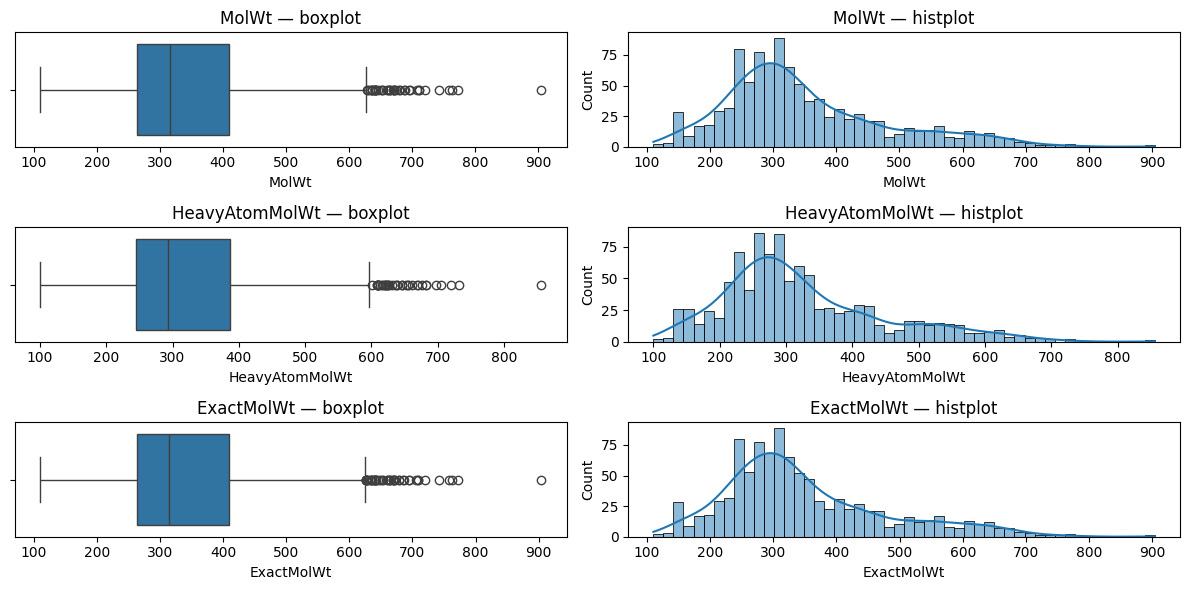


Группа: Electrons


,Feature,Mean,Median,Std,Skewness,Num of Outliers
0,NumValenceElectrons,132.266533,120.0,46.690654,0.262719,58
1,NumRadicalElectrons,0.000000,0.0,0.000000,0.000000,0


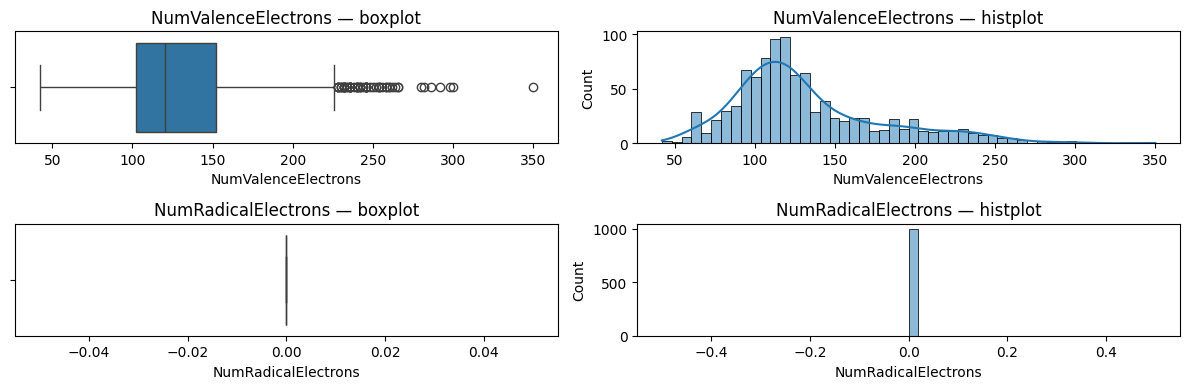


Группа: DensityMorgan


,Feature,Mean,Median,Std,Skewness,Num of Outliers
2,FpDensityMorgan3,2.417949,2.500000,0.396615,0.206878,50
1,FpDensityMorgan2,1.823665,1.875000,0.320619,0.160113,31
0,FpDensityMorgan1,1.142149,1.153846,0.240730,0.048588,3


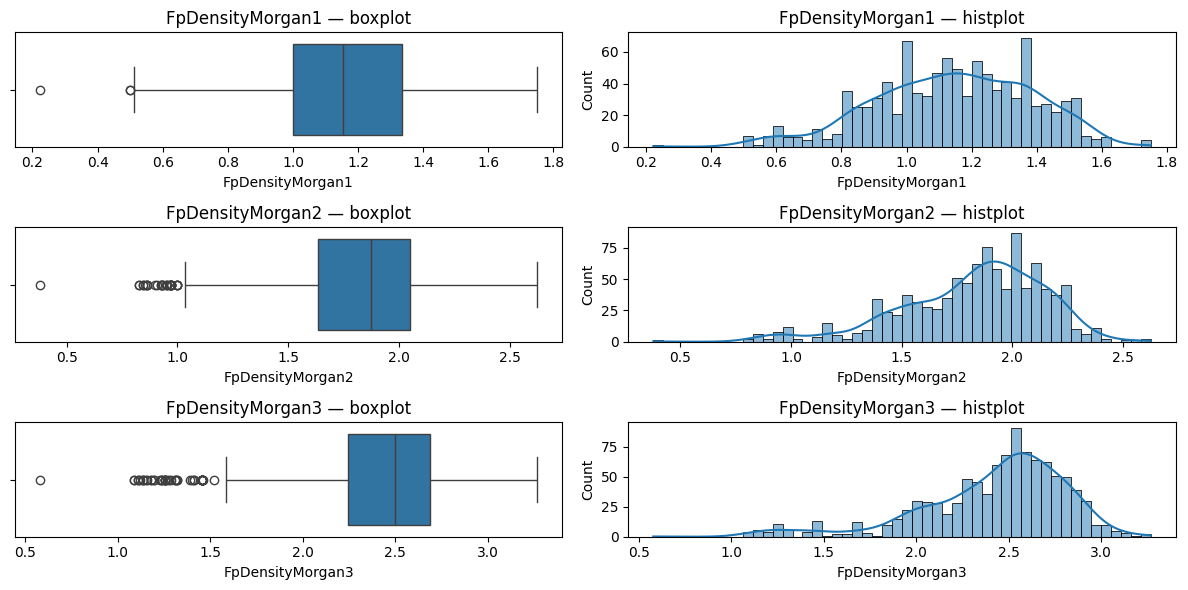


Группа: BCUT2D


,Feature,Mean,Median,Std,Skewness,Num of Outliers
6,BCUT2D_MRHI,6.295386,5.938573,1.090991,0.327054,153
7,BCUT2D_MRLOW,-0.069485,-0.113820,0.249599,0.177623,71
0,BCUT2D_MWHI,23.196621,16.564091,14.529014,0.456502,39
5,BCUT2D_LOGPLOW,-2.403494,-2.396486,0.177036,0.039586,38
2,BCUT2D_CHGHI,2.472204,2.505815,0.162113,0.207330,24
1,BCUT2D_MWLOW,9.792567,9.715411,0.461284,0.167263,8
4,BCUT2D_LOGPHI,2.473116,2.485135,0.157111,0.076501,4
3,BCUT2D_CHGLO,-2.347064,-2.358527,0.168873,0.067880,3


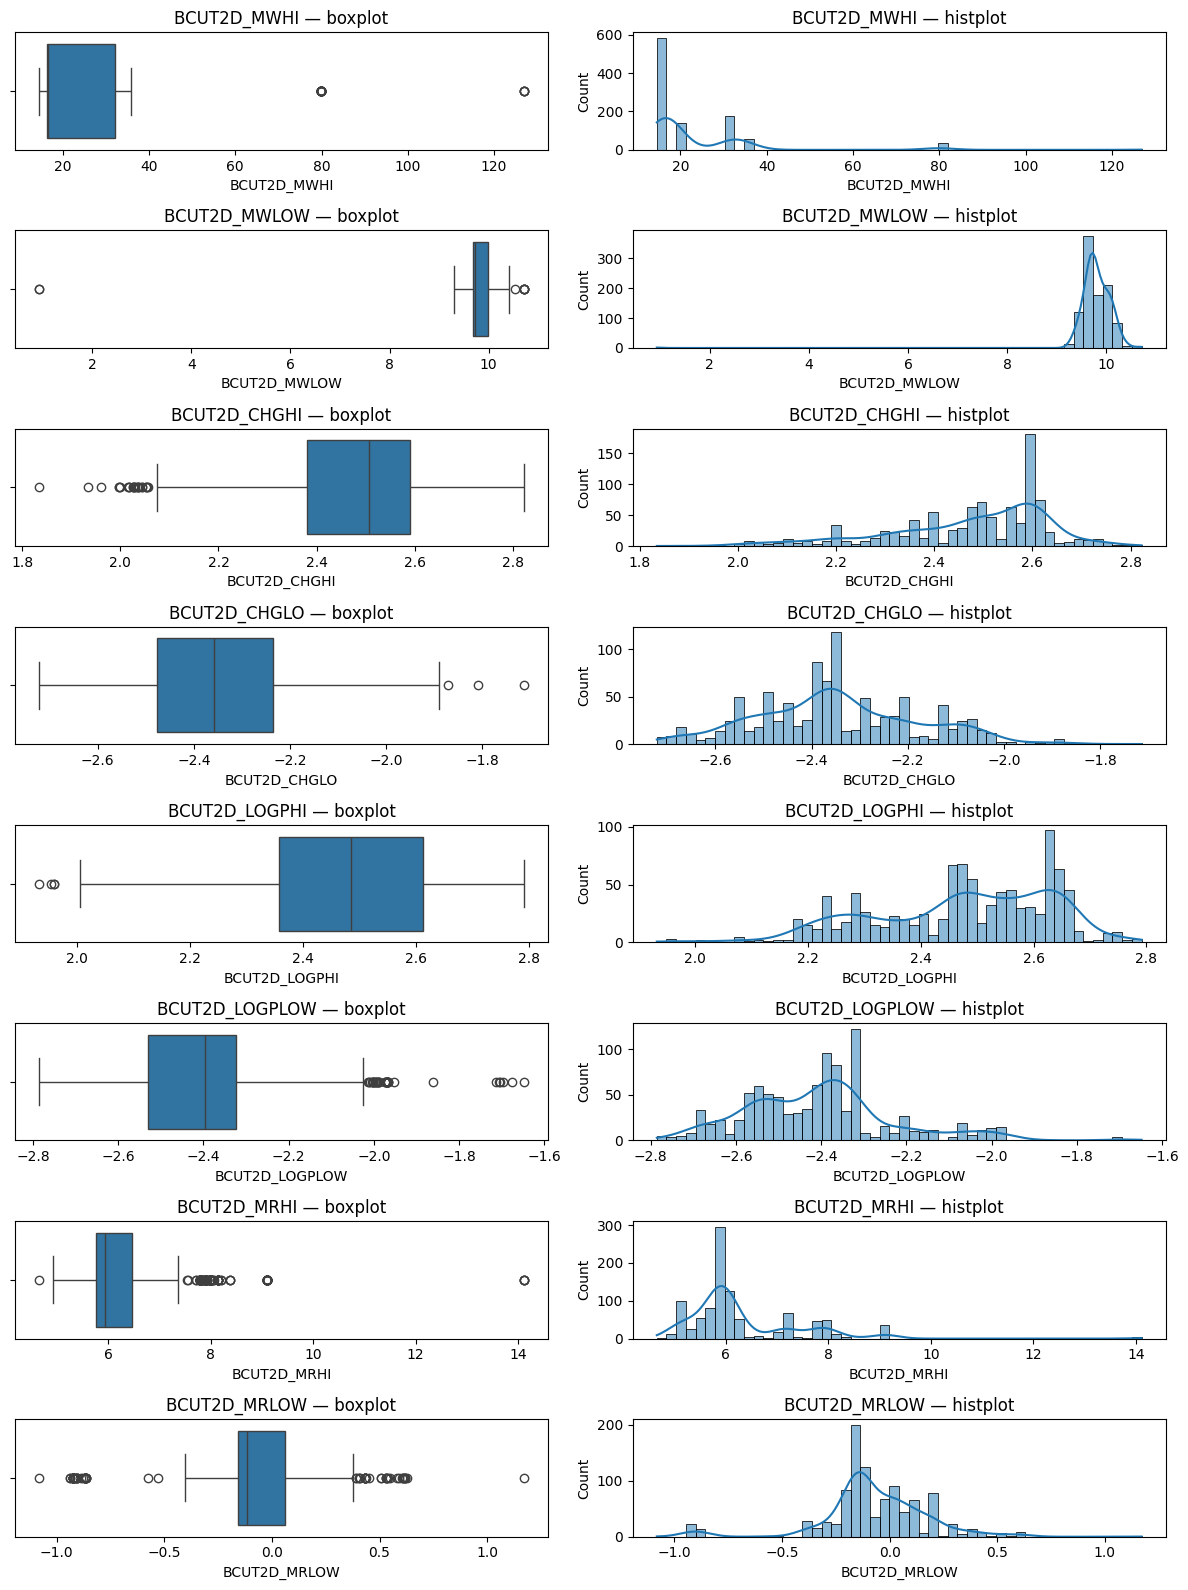


Группа: Chi


,Feature,Mean,Median,Std,Skewness,Num of Outliers
2,Chi0v,14.865323,13.635498,5.273326,0.233216,66
1,Chi0n,14.542068,13.307377,5.176562,0.238516,61
5,Chi1v,8.944827,8.091359,3.231320,0.264123,59
11,Chi4v,4.410549,4.079446,2.019475,0.163955,54
4,Chi1n,8.652970,7.921764,3.131328,0.233513,53
8,Chi3n,5.632550,5.138310,2.459568,0.200946,51
10,Chi4n,4.173875,3.858868,1.934112,0.162869,49
0,Chi0,17.683070,16.074921,6.312813,0.254744,42
9,Chi3v,5.915881,5.549494,2.535892,0.144481,42
3,Chi1,11.741093,10.442443,4.433516,0.292917,39


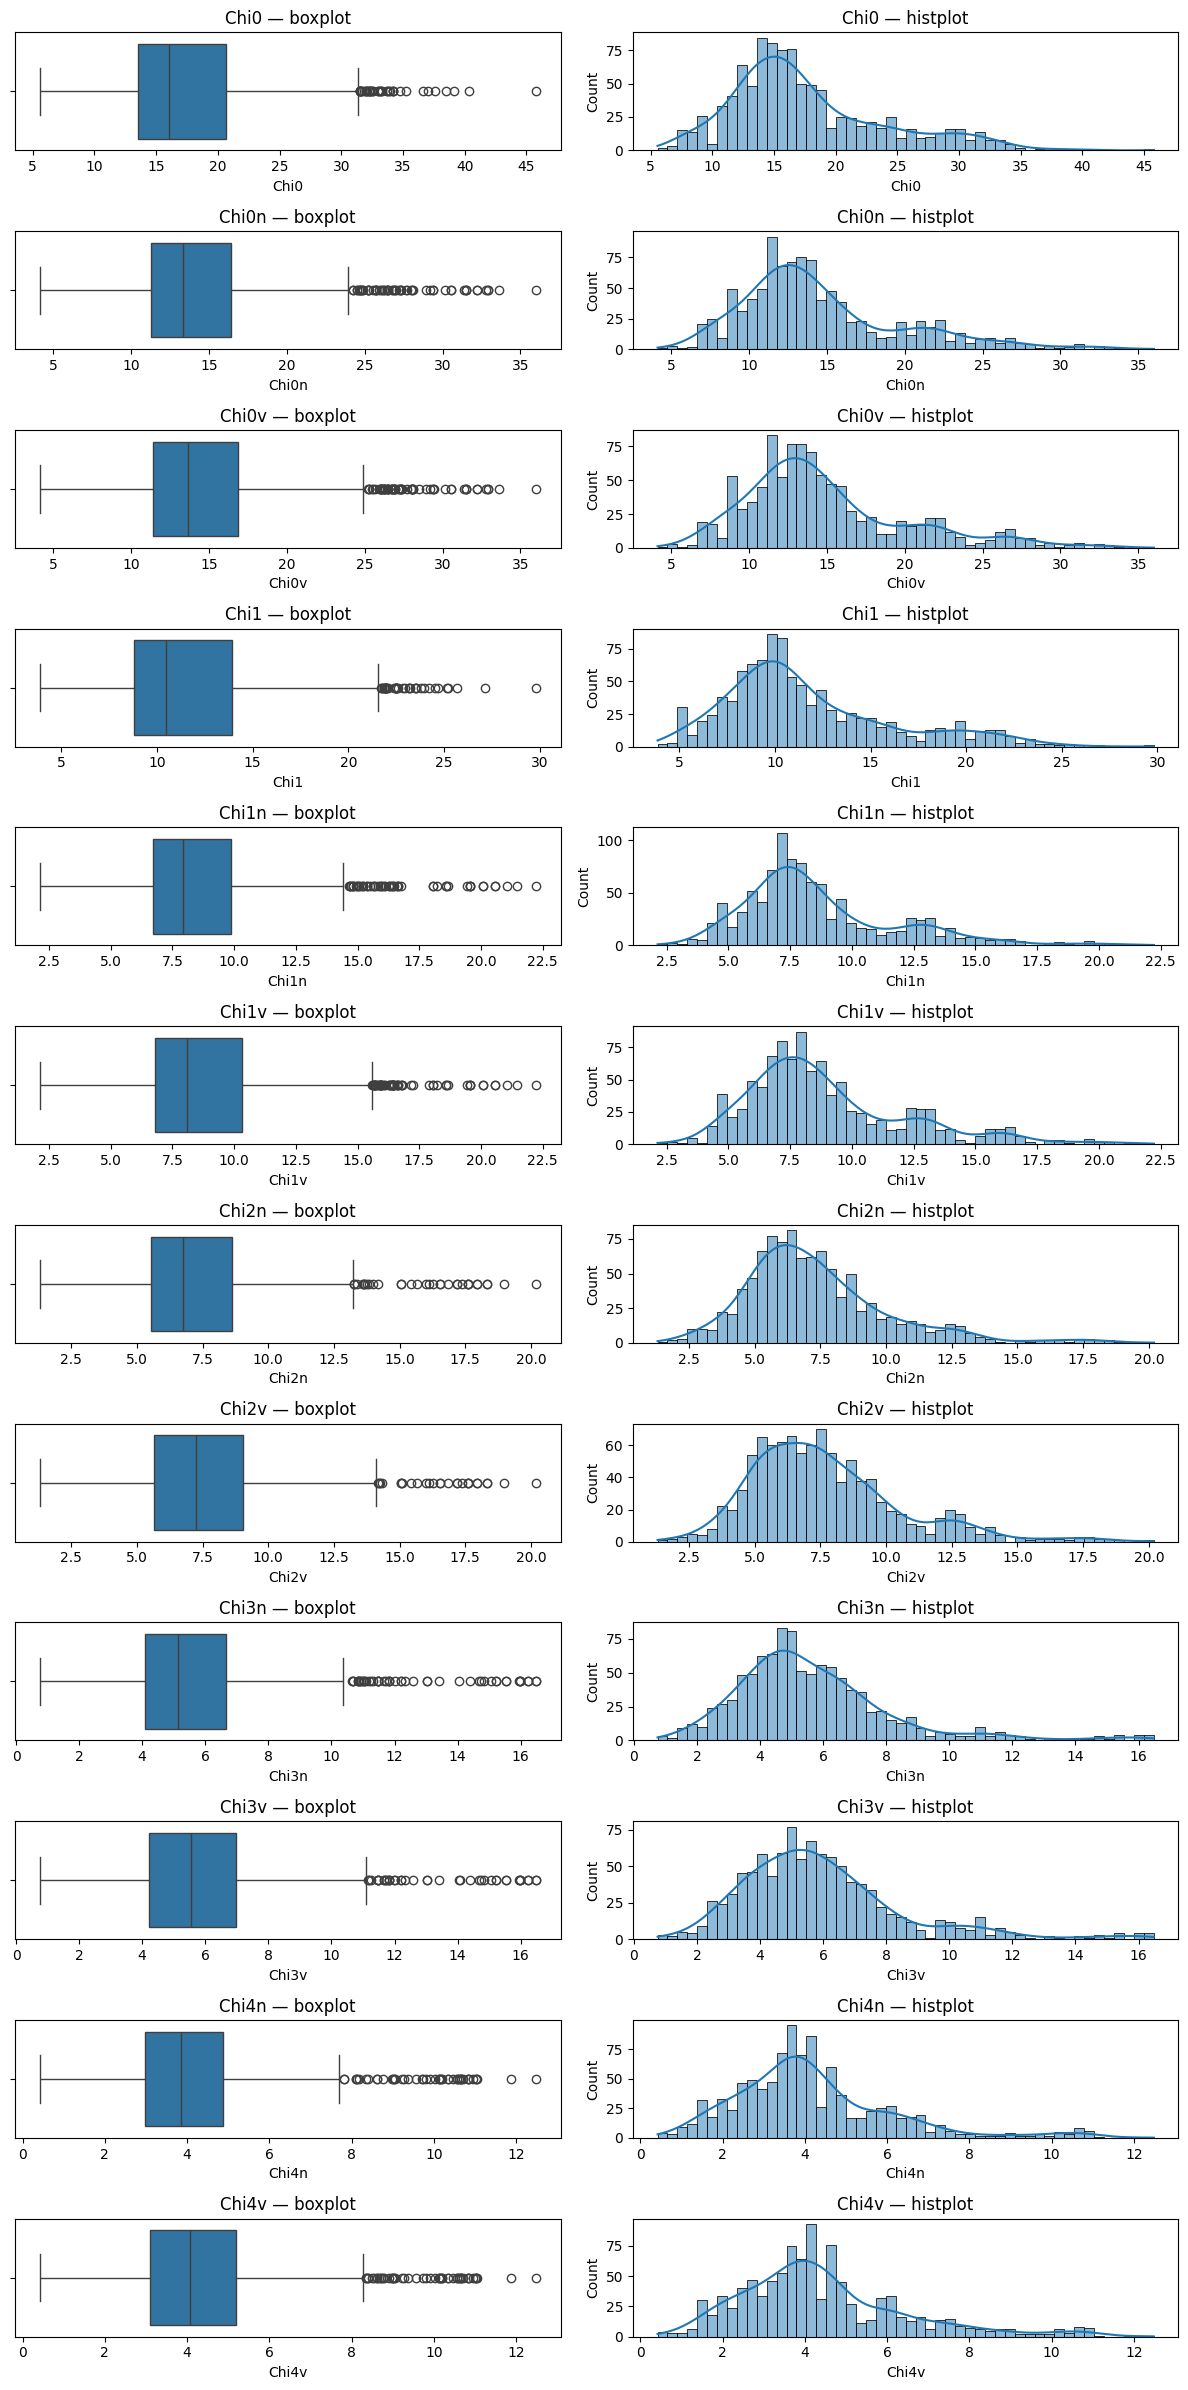


Группа: Kappa


,Feature,Mean,Median,Std,Skewness,Num of Outliers
2,Kappa3,3.090964,2.678303,1.723720,0.239401,64
1,Kappa2,6.383941,5.674880,3.006885,0.235812,63
0,Kappa1,17.034796,15.675499,6.374384,0.213244,47


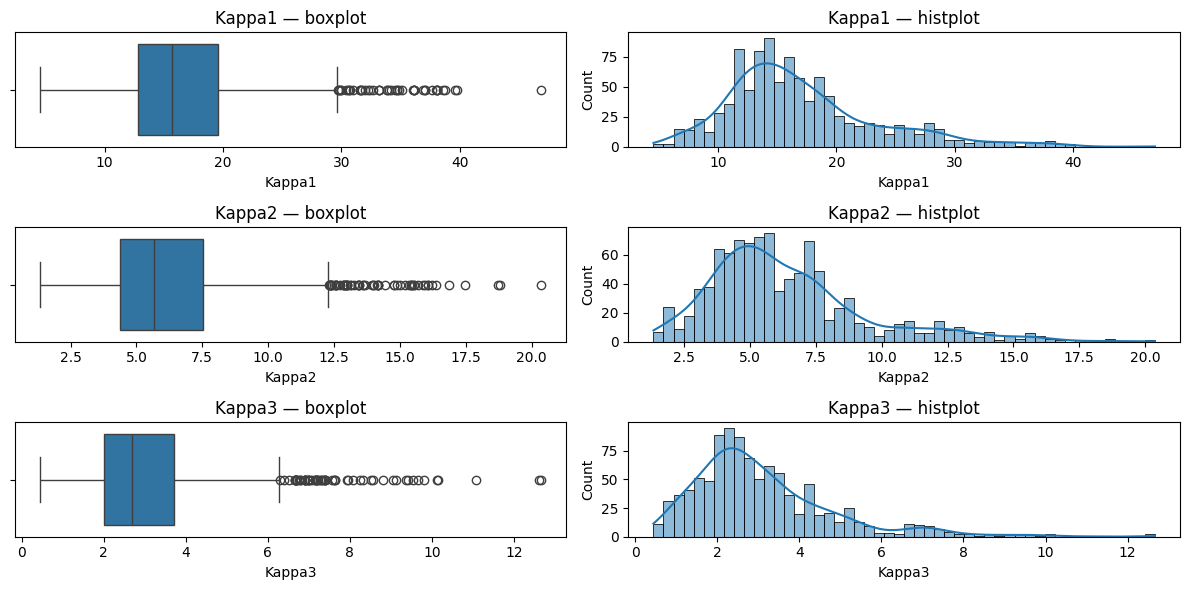


Группа: PEOE_VSA


,Feature,Mean,Median,Std,Skewness,Num of Outliers
3,PEOE_VSA4,2.956084,0.000000,6.731609,0.439135,205
12,PEOE_VSA13,1.185002,0.000000,2.627704,0.450965,185
4,PEOE_VSA5,1.766091,0.000000,4.399393,0.401440,166
10,PEOE_VSA11,5.008297,0.000000,8.950072,0.559582,123
11,PEOE_VSA12,3.420710,0.000000,5.467964,0.625591,69
9,PEOE_VSA10,8.087526,5.693928,12.620288,0.189663,52
2,PEOE_VSA3,2.991866,0.000000,4.965286,0.602557,49
6,PEOE_VSA7,41.644041,38.063890,21.730994,0.164749,42
0,PEOE_VSA1,12.667557,9.883888,11.590004,0.240178,40
8,PEOE_VSA9,14.807168,12.294268,12.521307,0.200690,34


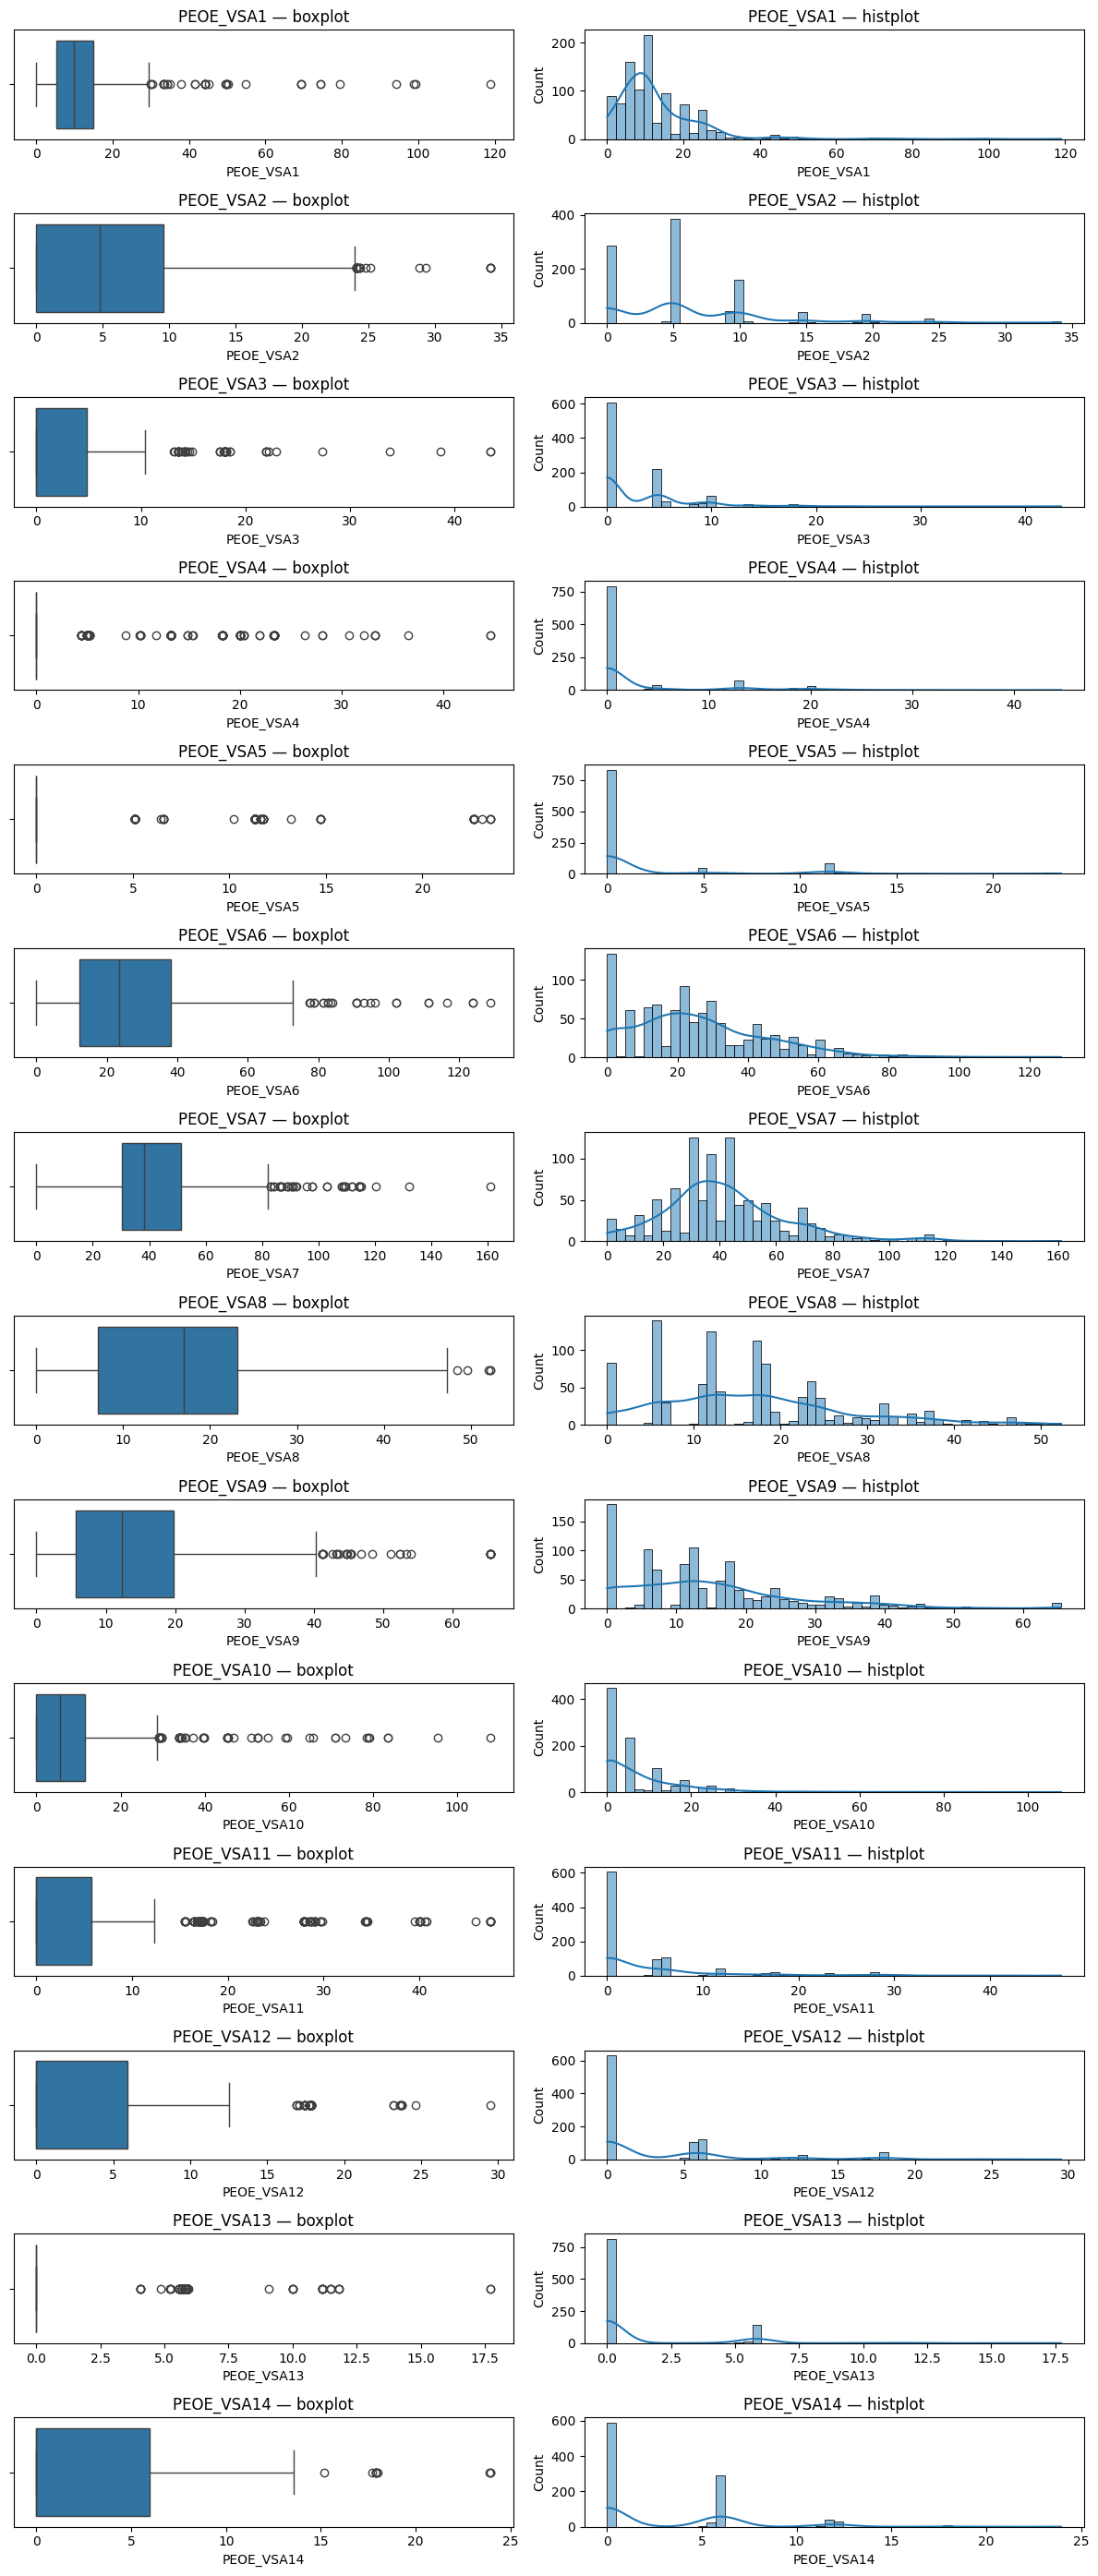


Группа: SMR_VSA


,Feature,Mean,Median,Std,Skewness,Num of Outliers
8,SMR_VSA9,5.747123,0.000000,10.978125,0.523507,141
5,SMR_VSA6,13.487504,7.109798,16.248702,0.392506,48
4,SMR_VSA5,41.761834,40.033676,29.570657,0.058442,27
9,SMR_VSA10,15.009370,11.617674,13.101635,0.258876,23
3,SMR_VSA4,11.809564,5.917906,12.231017,0.481698,22
0,SMR_VSA1,15.715628,14.233805,13.492862,0.109823,20
2,SMR_VSA3,5.263267,4.899910,6.618883,0.054897,12
1,SMR_VSA2,0.058843,0.000000,0.557751,0.105501,11
7,SMR_VSA8,0.000000,0.000000,0.000000,0.000000,0
6,SMR_VSA7,37.749540,34.905812,31.752546,0.089559,0


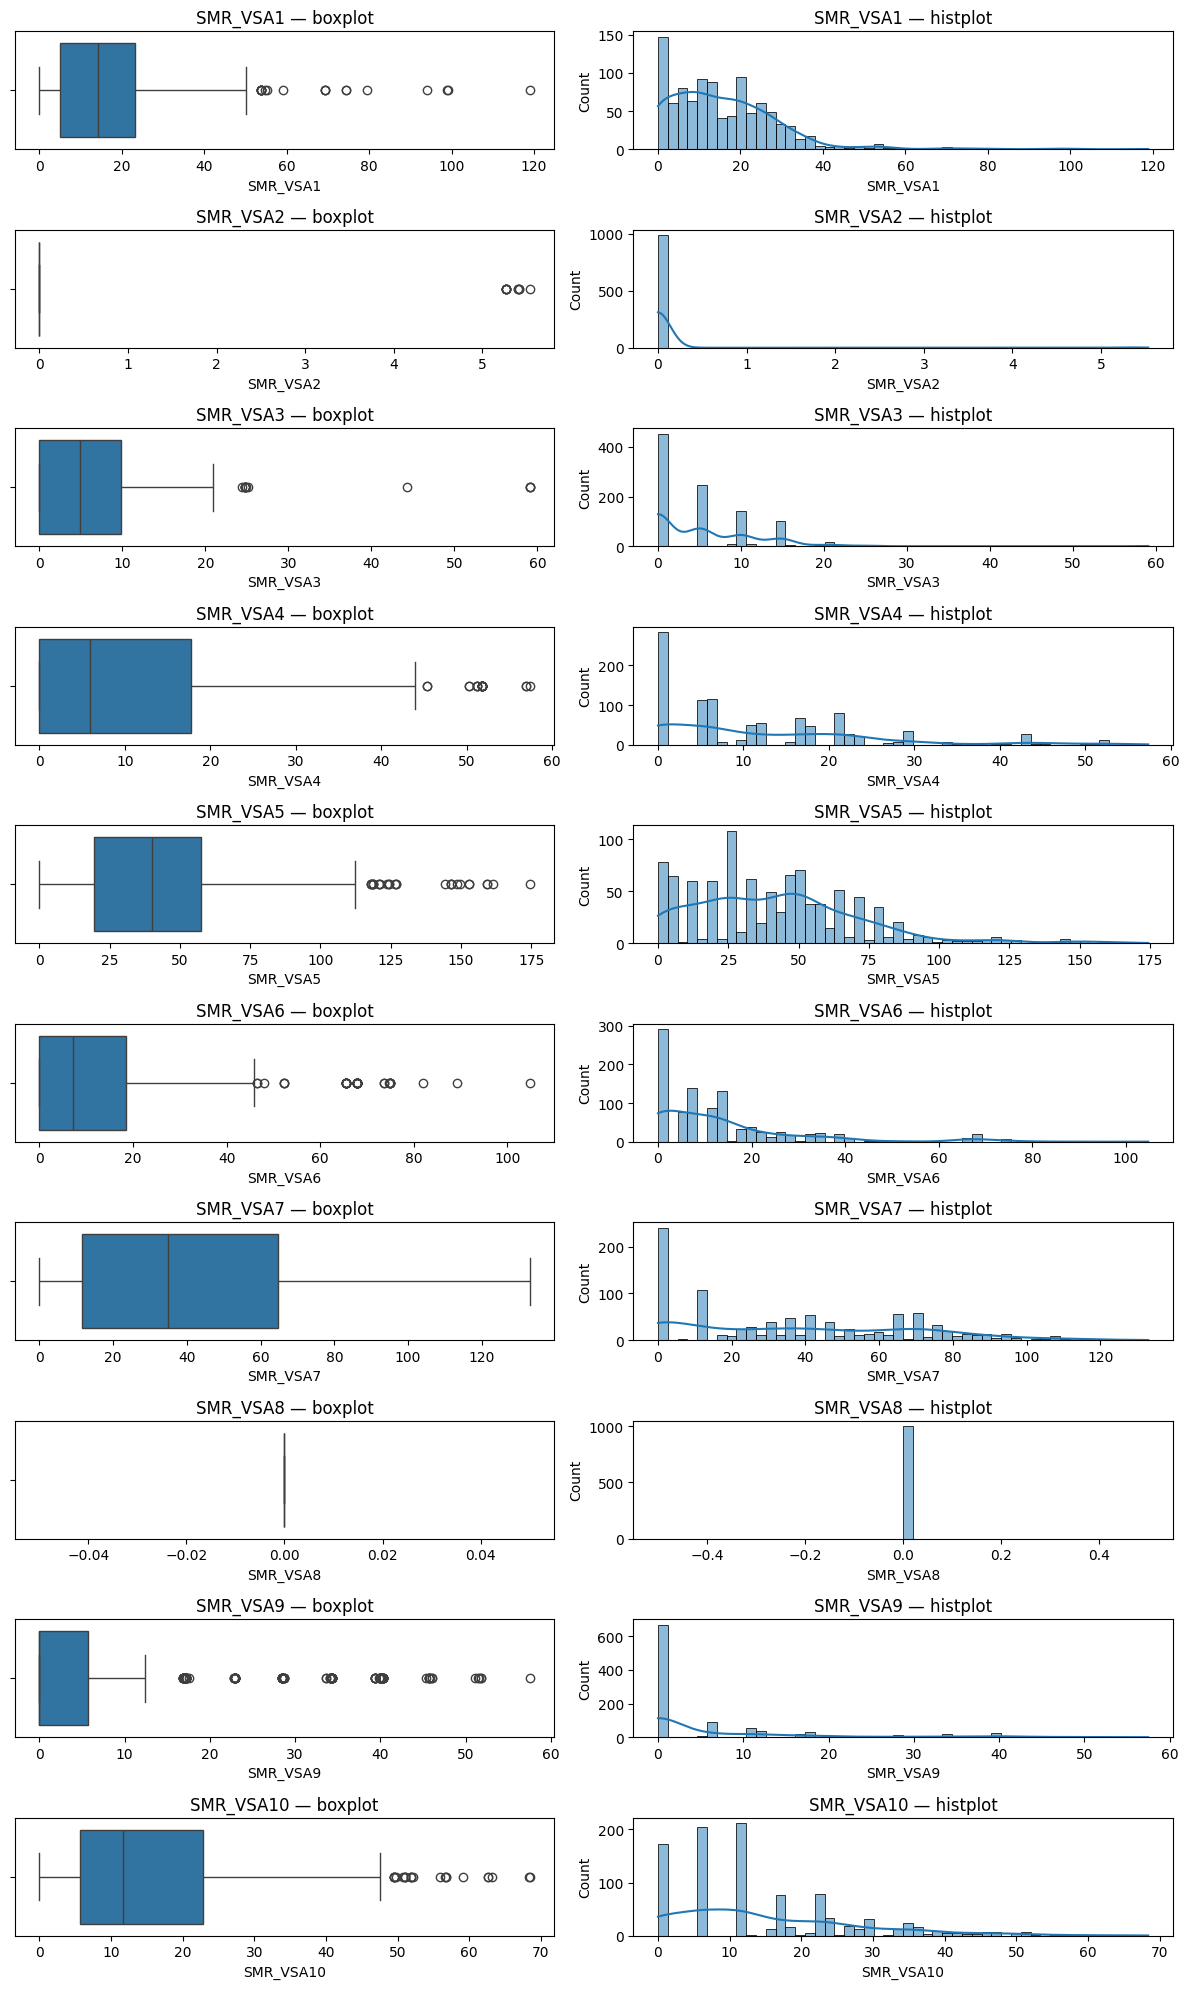


Группа: SlogP_VSA


,Feature,Mean,Median,Std,Skewness,Num of Outliers
10,SlogP_VSA11,3.781069,0.000000,8.457077,0.447089,109
9,SlogP_VSA10,4.584109,0.000000,7.225625,0.634424,107
7,SlogP_VSA8,4.025493,0.000000,7.195939,0.559412,103
11,SlogP_VSA12,4.073932,0.000000,7.952837,0.512262,73
6,SlogP_VSA7,0.305247,0.000000,1.388712,0.219806,55
4,SlogP_VSA5,39.710601,40.033676,26.588237,0.012151,36
2,SlogP_VSA3,8.226307,6.176299,7.726373,0.265326,33
3,SlogP_VSA4,11.945688,11.332897,11.000845,0.055704,22
1,SlogP_VSA2,32.978342,27.906531,23.767016,0.213397,16
0,SlogP_VSA1,6.067502,5.316789,6.182729,0.121421,8


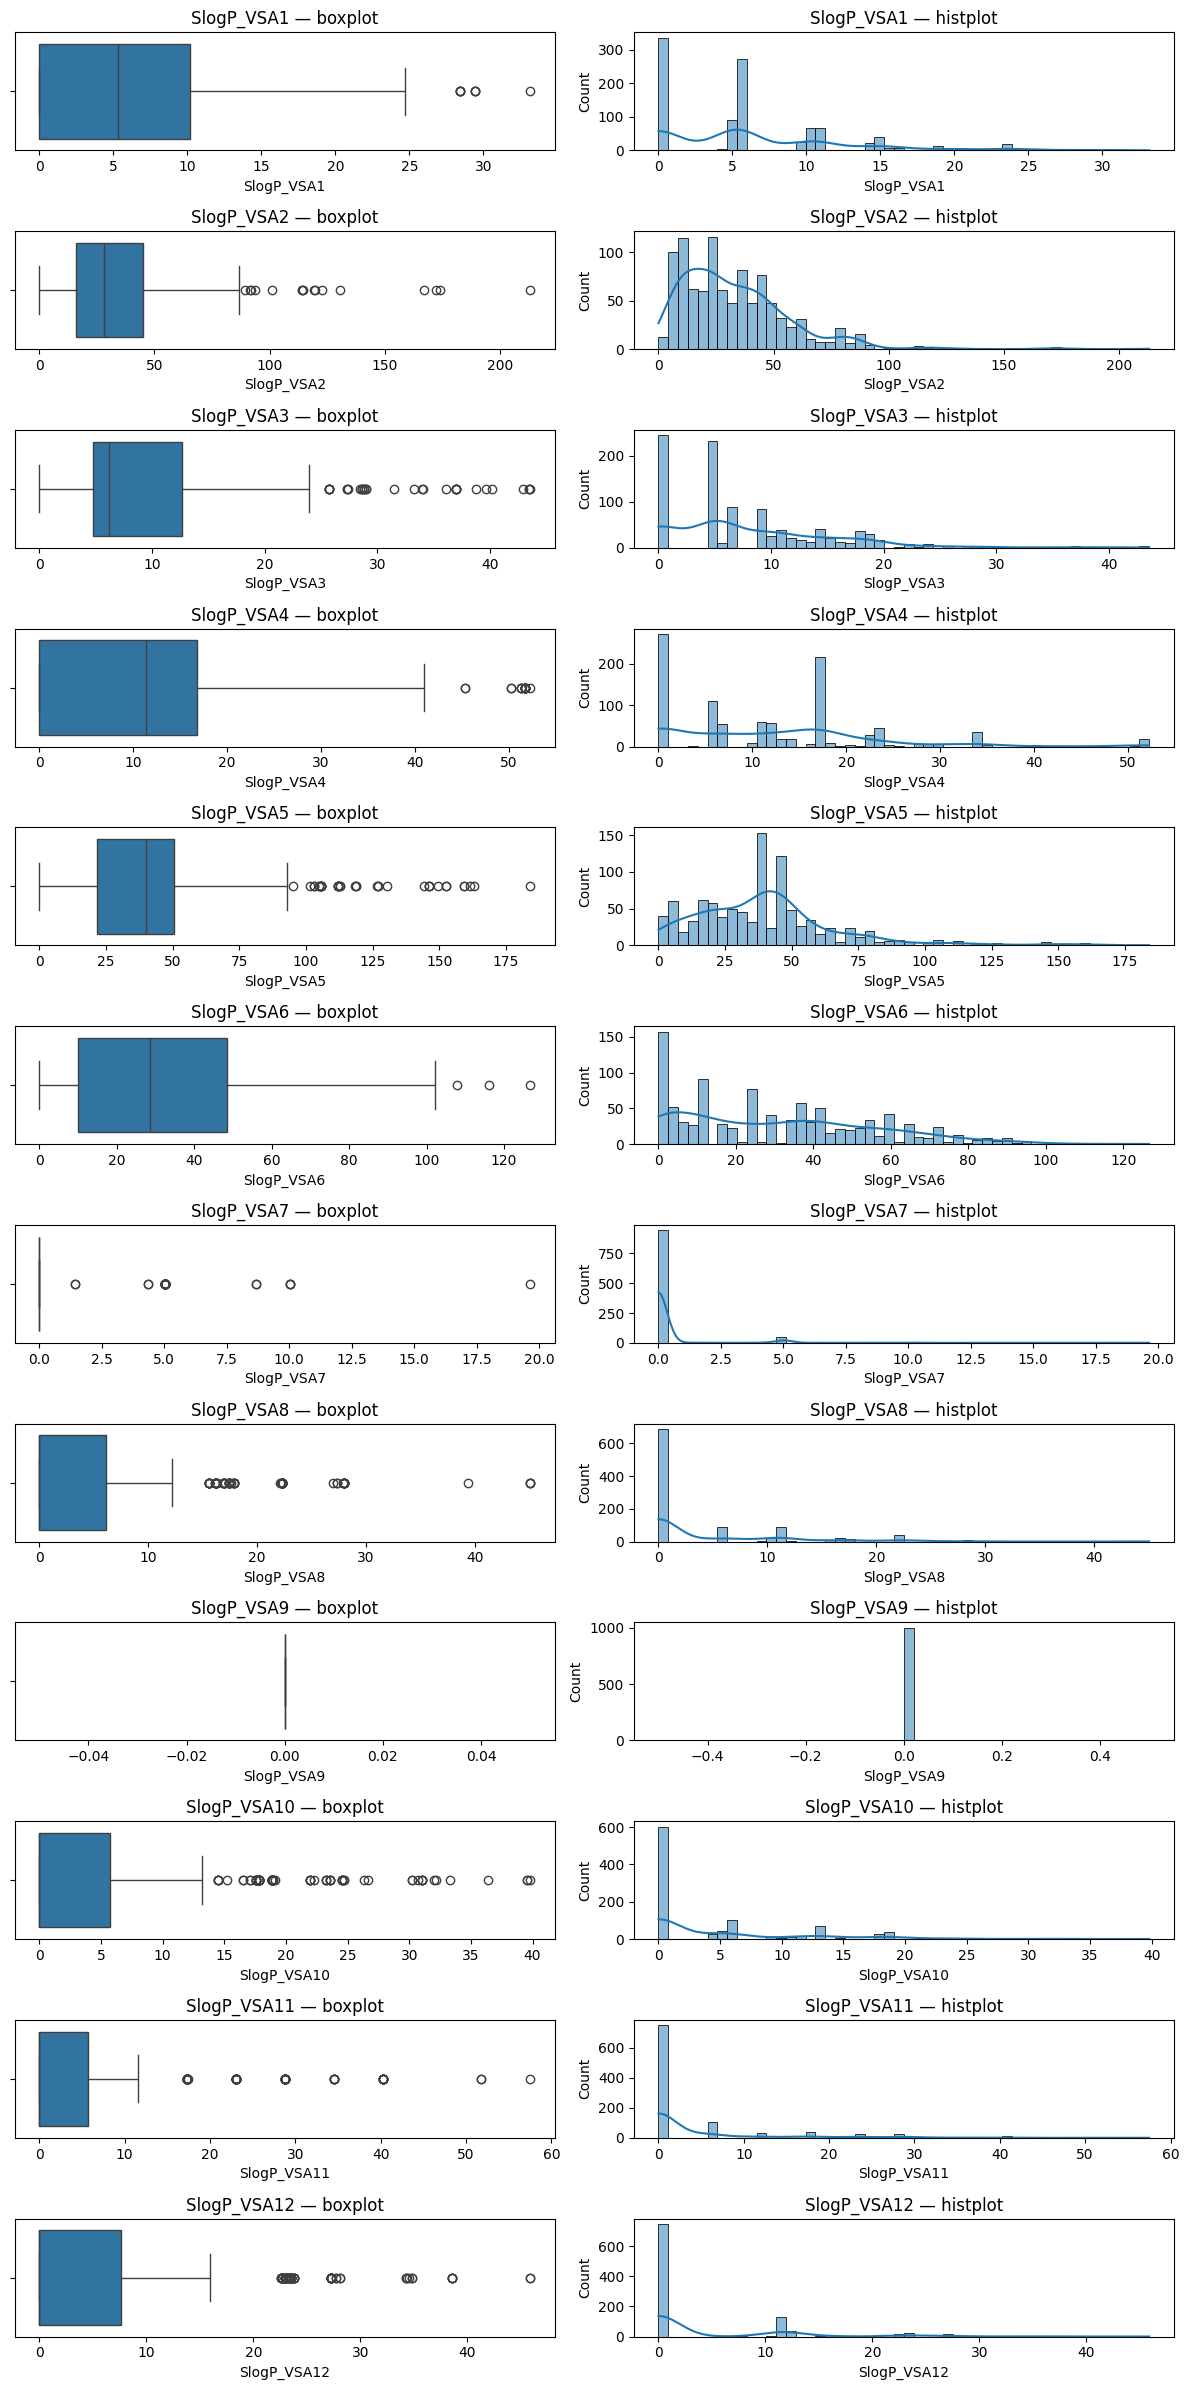


Группа: state_index


,Feature,Mean,Median,Std,Skewness,Num of Outliers
3,MinEStateIndex,-0.966330,-0.419485,1.590258,0.343872,128
2,MinAbsEStateIndex,0.180888,0.124656,0.168860,0.333012,21
1,MaxEStateIndex,10.829292,12.187546,3.312200,0.410076,19
0,MaxAbsEStateIndex,10.829292,12.187546,3.312200,0.410076,19


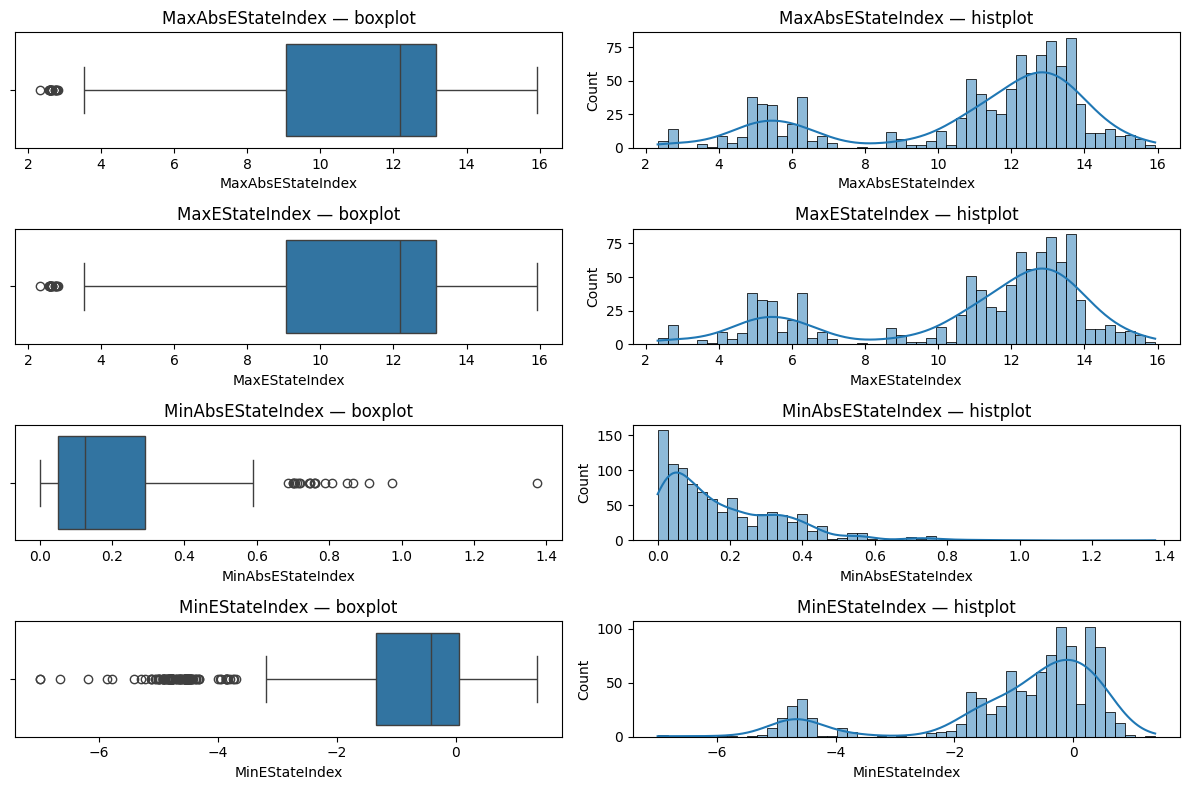


Группа: partial_charge


,Feature,Mean,Median,Std,Skewness,Num of Outliers
1,MinPartialCharge,-0.407436,-0.393567,0.075974,0.182558,5
2,MaxAbsPartialCharge,0.415741,0.426056,0.071951,0.143355,4
0,MaxPartialCharge,0.235749,0.250661,0.129429,0.115209,0
3,MinAbsPartialCharge,0.227534,0.250661,0.119641,0.193304,0


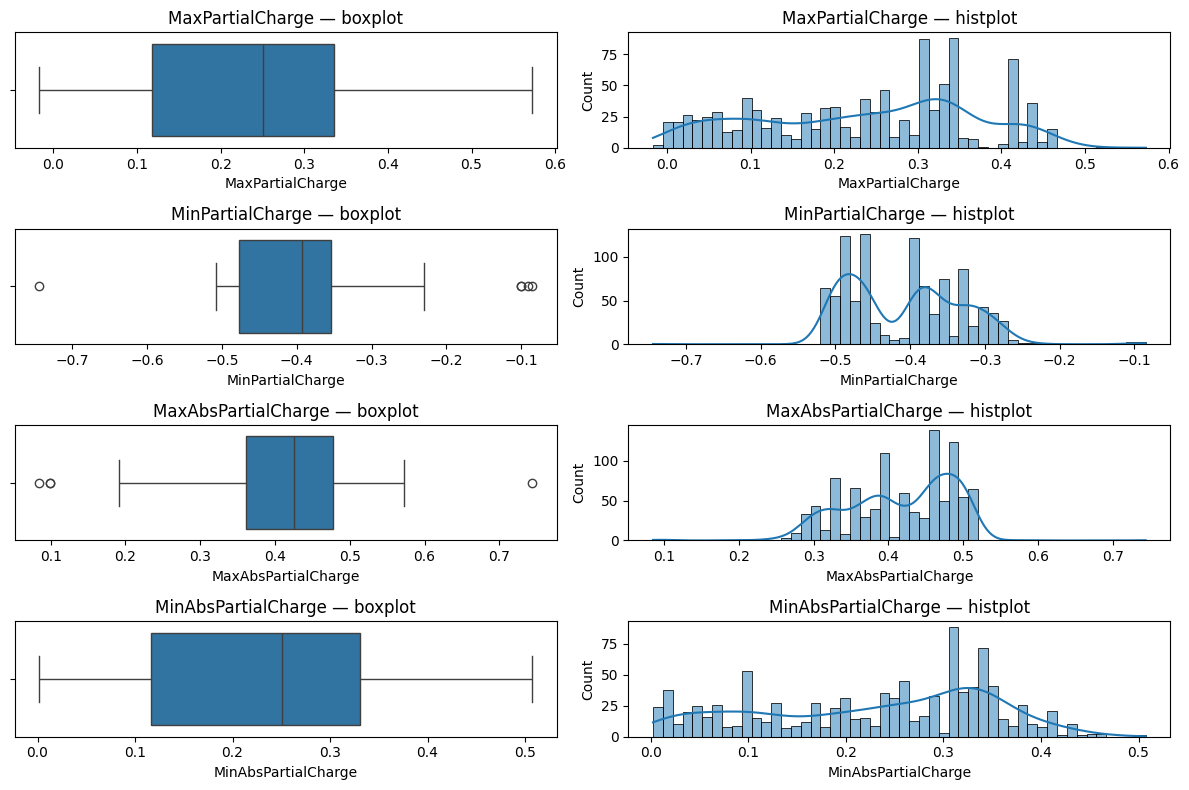


Группа: EState_VSA


,Feature,Mean,Median,Std,Skewness,Num of Outliers
1,EState_VSA2,13.264498,11.401284,12.227635,0.152377,57
2,EState_VSA3,16.342009,12.185486,13.871000,0.299656,52
0,EState_VSA1,12.424856,5.601051,18.772906,0.363492,49
4,EState_VSA5,19.096495,12.682902,22.500345,0.285044,48
6,EState_VSA7,13.992766,4.899910,19.932078,0.456192,42
3,EState_VSA4,20.290526,17.753718,13.790903,0.183948,41
8,EState_VSA9,8.918217,5.733667,8.482479,0.375427,41
10,EState_VSA11,0.140775,0.000000,0.952986,0.147720,26
9,EState_VSA10,10.155864,5.106527,10.631168,0.474956,25
5,EState_VSA6,11.518637,6.214601,13.654767,0.388438,20


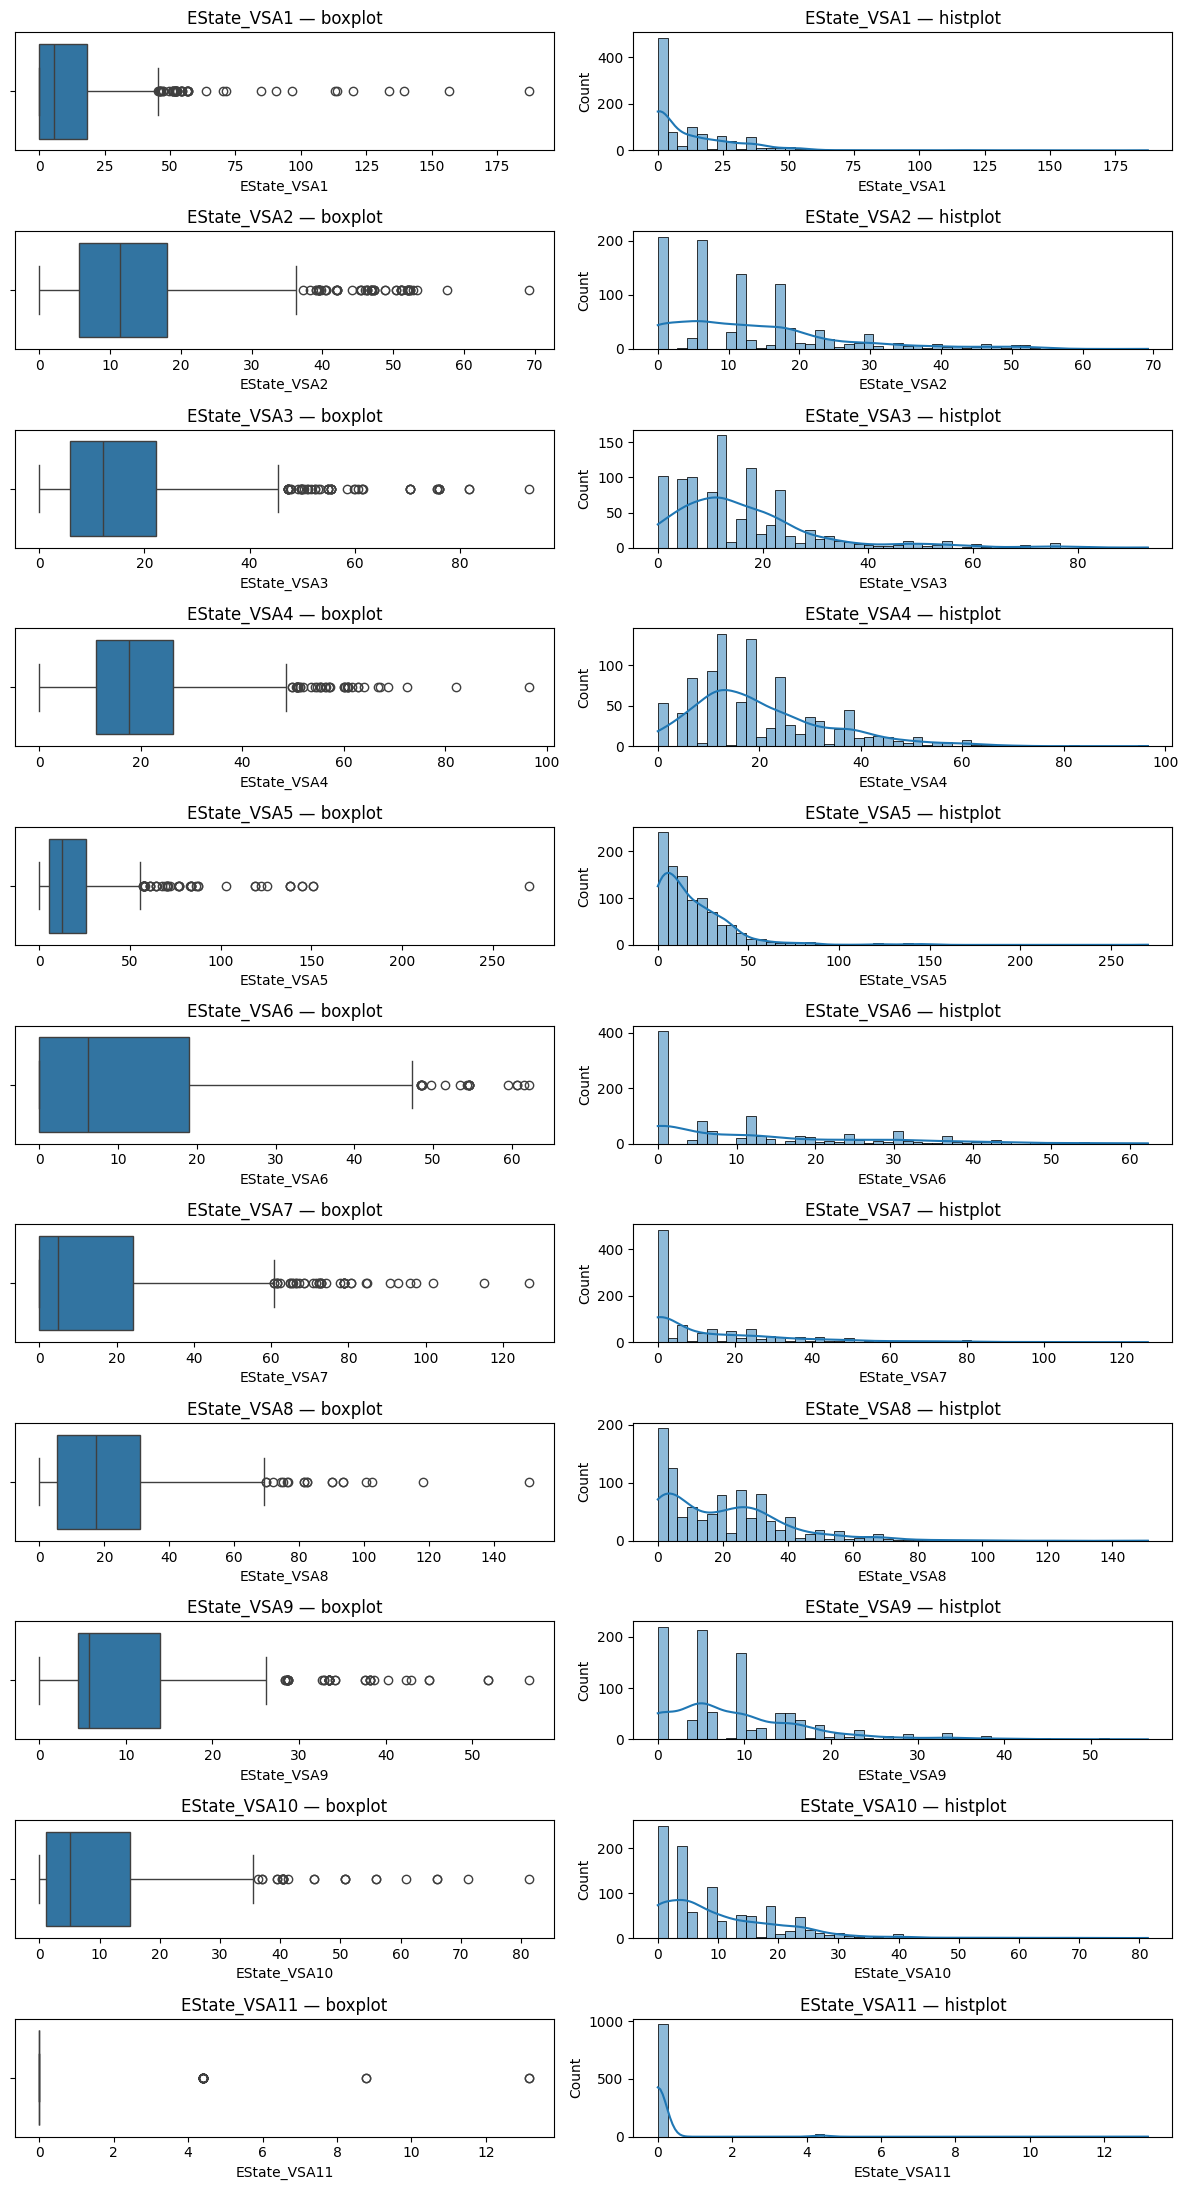


Группа: VSA_EState


,Feature,Mean,Median,Std,Skewness,Num of Outliers
9,VSA_EState10,1.005513,0.000000,2.230156,0.450871,247
8,VSA_EState9,0.569104,0.000000,1.684041,0.337939,243
2,VSA_EState3,9.136847,3.854685,15.207940,0.347329,63
4,VSA_EState5,0.026755,0.645064,2.567369,0.240834,58
0,VSA_EState1,14.665407,6.480347,18.099096,0.452236,39
7,VSA_EState8,5.424391,4.266109,5.714723,0.202684,31
1,VSA_EState2,14.631311,12.357712,13.535545,0.167972,30
6,VSA_EState7,3.237029,3.630617,5.344098,0.073649,30
5,VSA_EState6,6.564832,5.485944,7.021234,0.153661,17
3,VSA_EState4,2.178894,1.961914,2.904382,0.074708,9


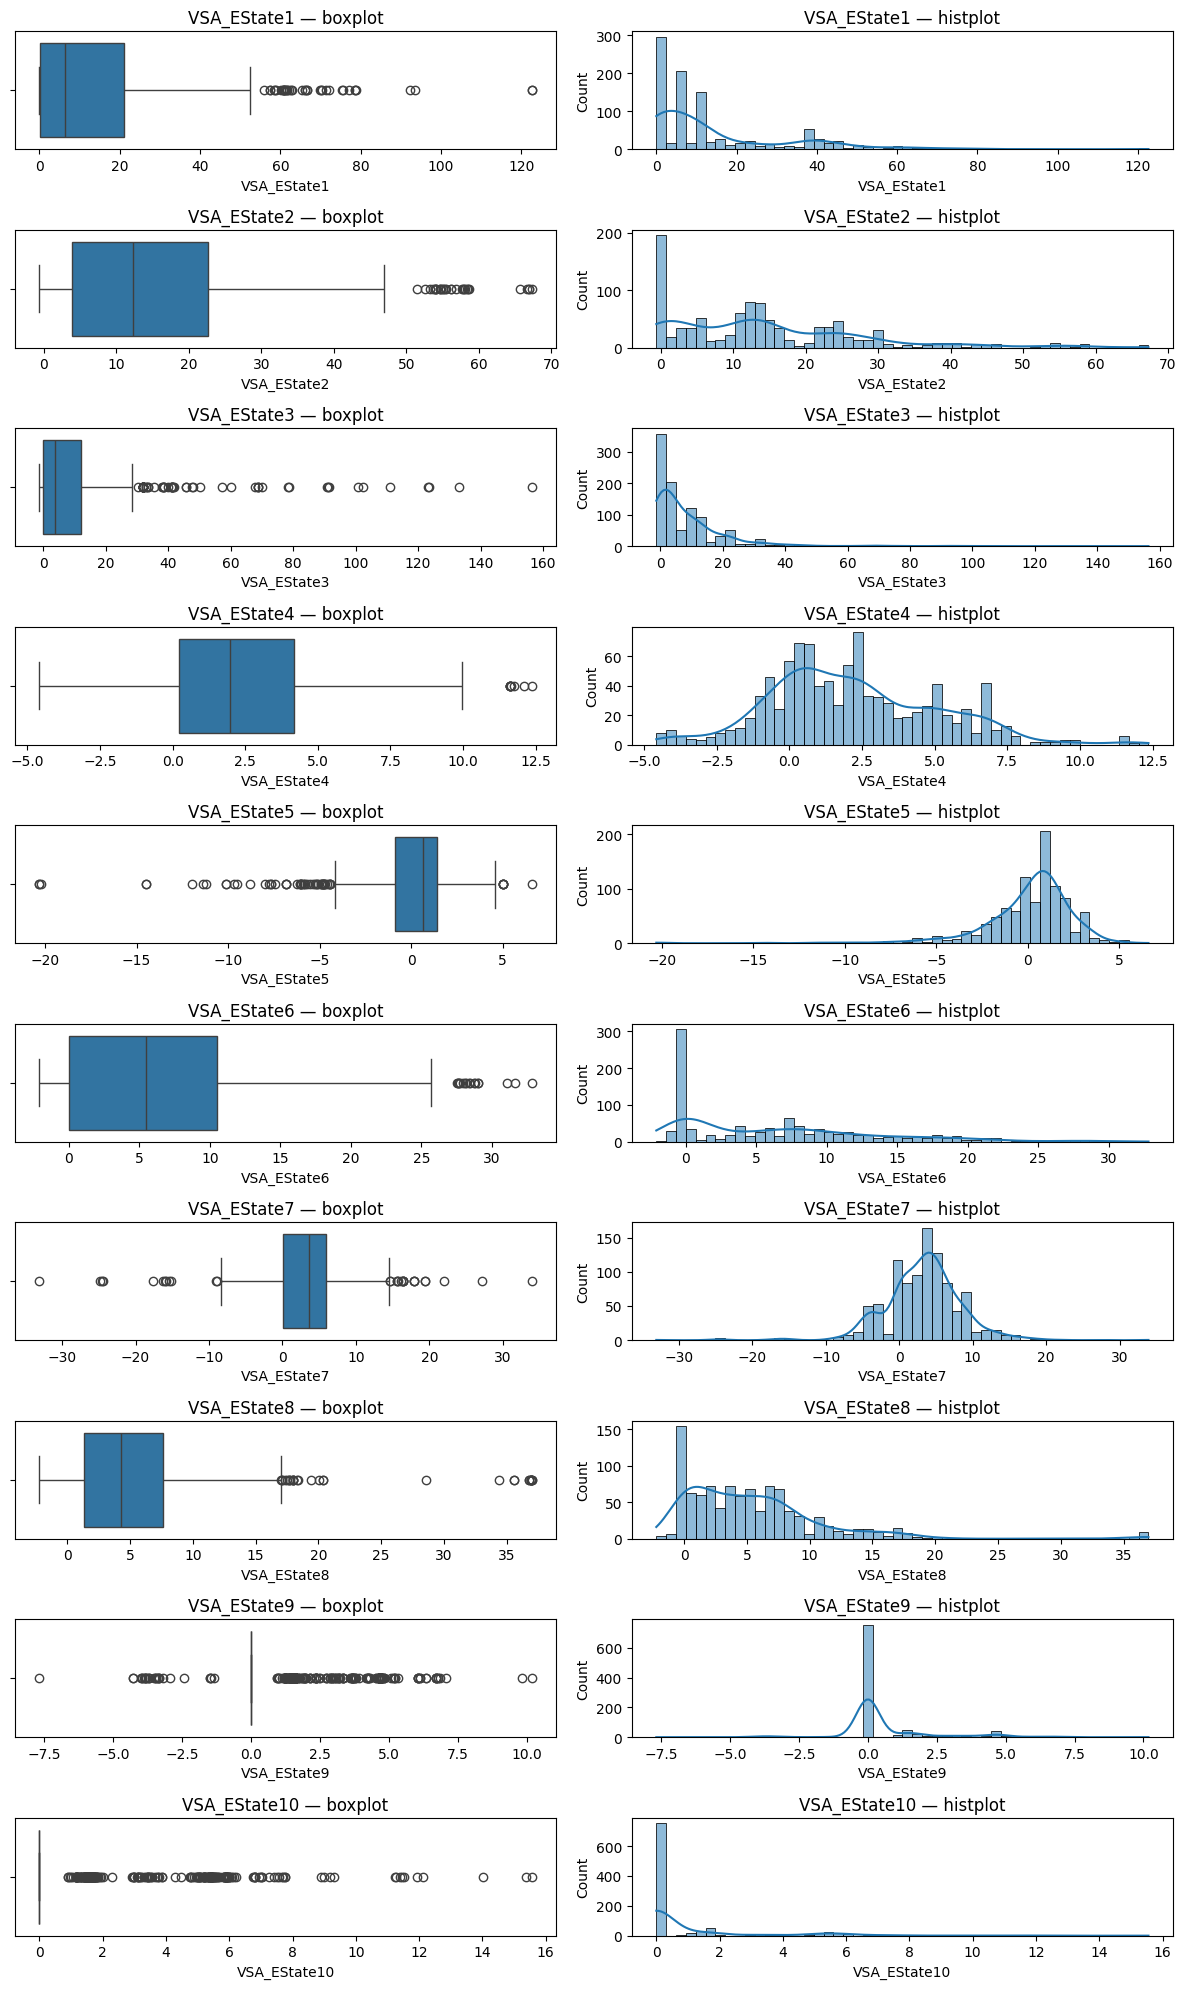


Группа: MolDescriptors


,Feature,Mean,Median,Std,Skewness,Num of Outliers
0,MolLogP,3.453096,3.4252,2.126334,0.013119,62
1,MolMR,94.306852,85.7198,34.417299,0.249498,56


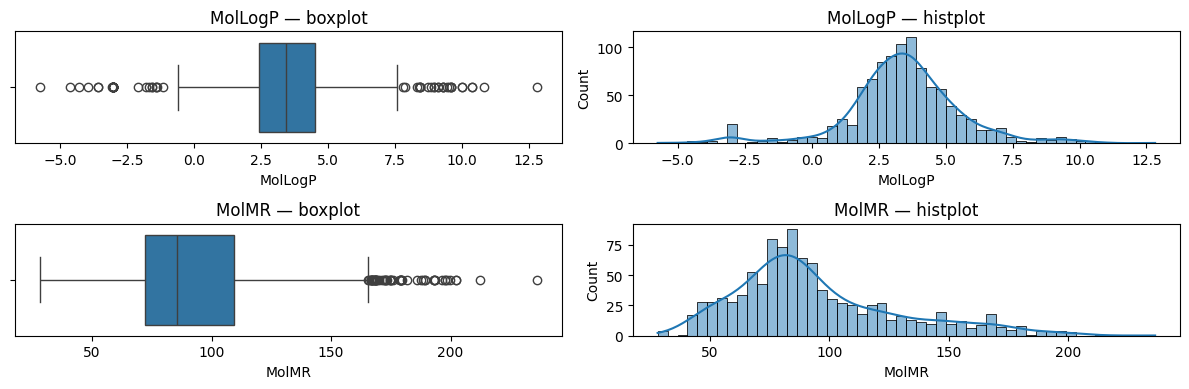


Группа: AtomRingCount


,Feature,Mean,Median,Std,Skewness,Num of Outliers
0,HeavyAtomCount,24.676353,22.0,9.072121,0.295009,41
3,RingCount,3.567134,3.0,1.574942,0.360098,28
1,NHOHCount,1.321643,1.0,1.705426,0.188600,23
2,NOCount,4.672345,4.0,3.196327,0.210349,17


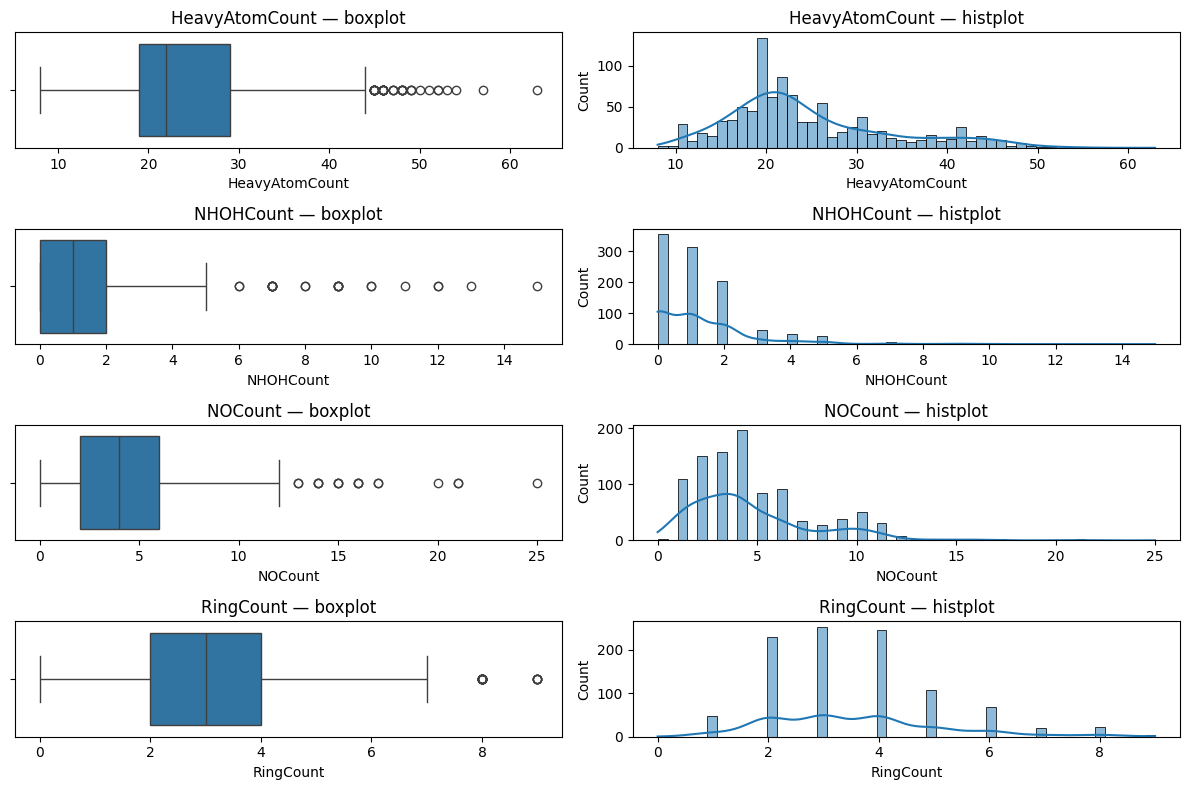


Группа: NumDescriptors


,Feature,Mean,Median,Std,Skewness,Num of Outliers
6,NumHAcceptors,4.324649,3.5,3.200867,0.257633,96
9,NumRotatableBonds,3.843687,3.0,3.266132,0.258314,44
7,NumHDonors,1.185371,1.0,1.590060,0.116581,23
8,NumHeteroatoms,5.570140,5.0,3.502197,0.162795,20
0,NumAliphaticCarbocycles,1.230461,1.0,1.455799,0.158305,15
4,NumAromaticHeterocycles,0.508016,0.0,0.721803,0.703816,15
11,NumSaturatedHeterocycles,0.529058,0.0,0.796593,0.664151,11
2,NumAliphaticRings,2.095190,2.0,1.357751,0.070109,8
5,NumAromaticRings,1.471944,1.0,1.395190,0.338265,7
12,NumSaturatedRings,1.496994,1.0,1.359056,0.365691,3


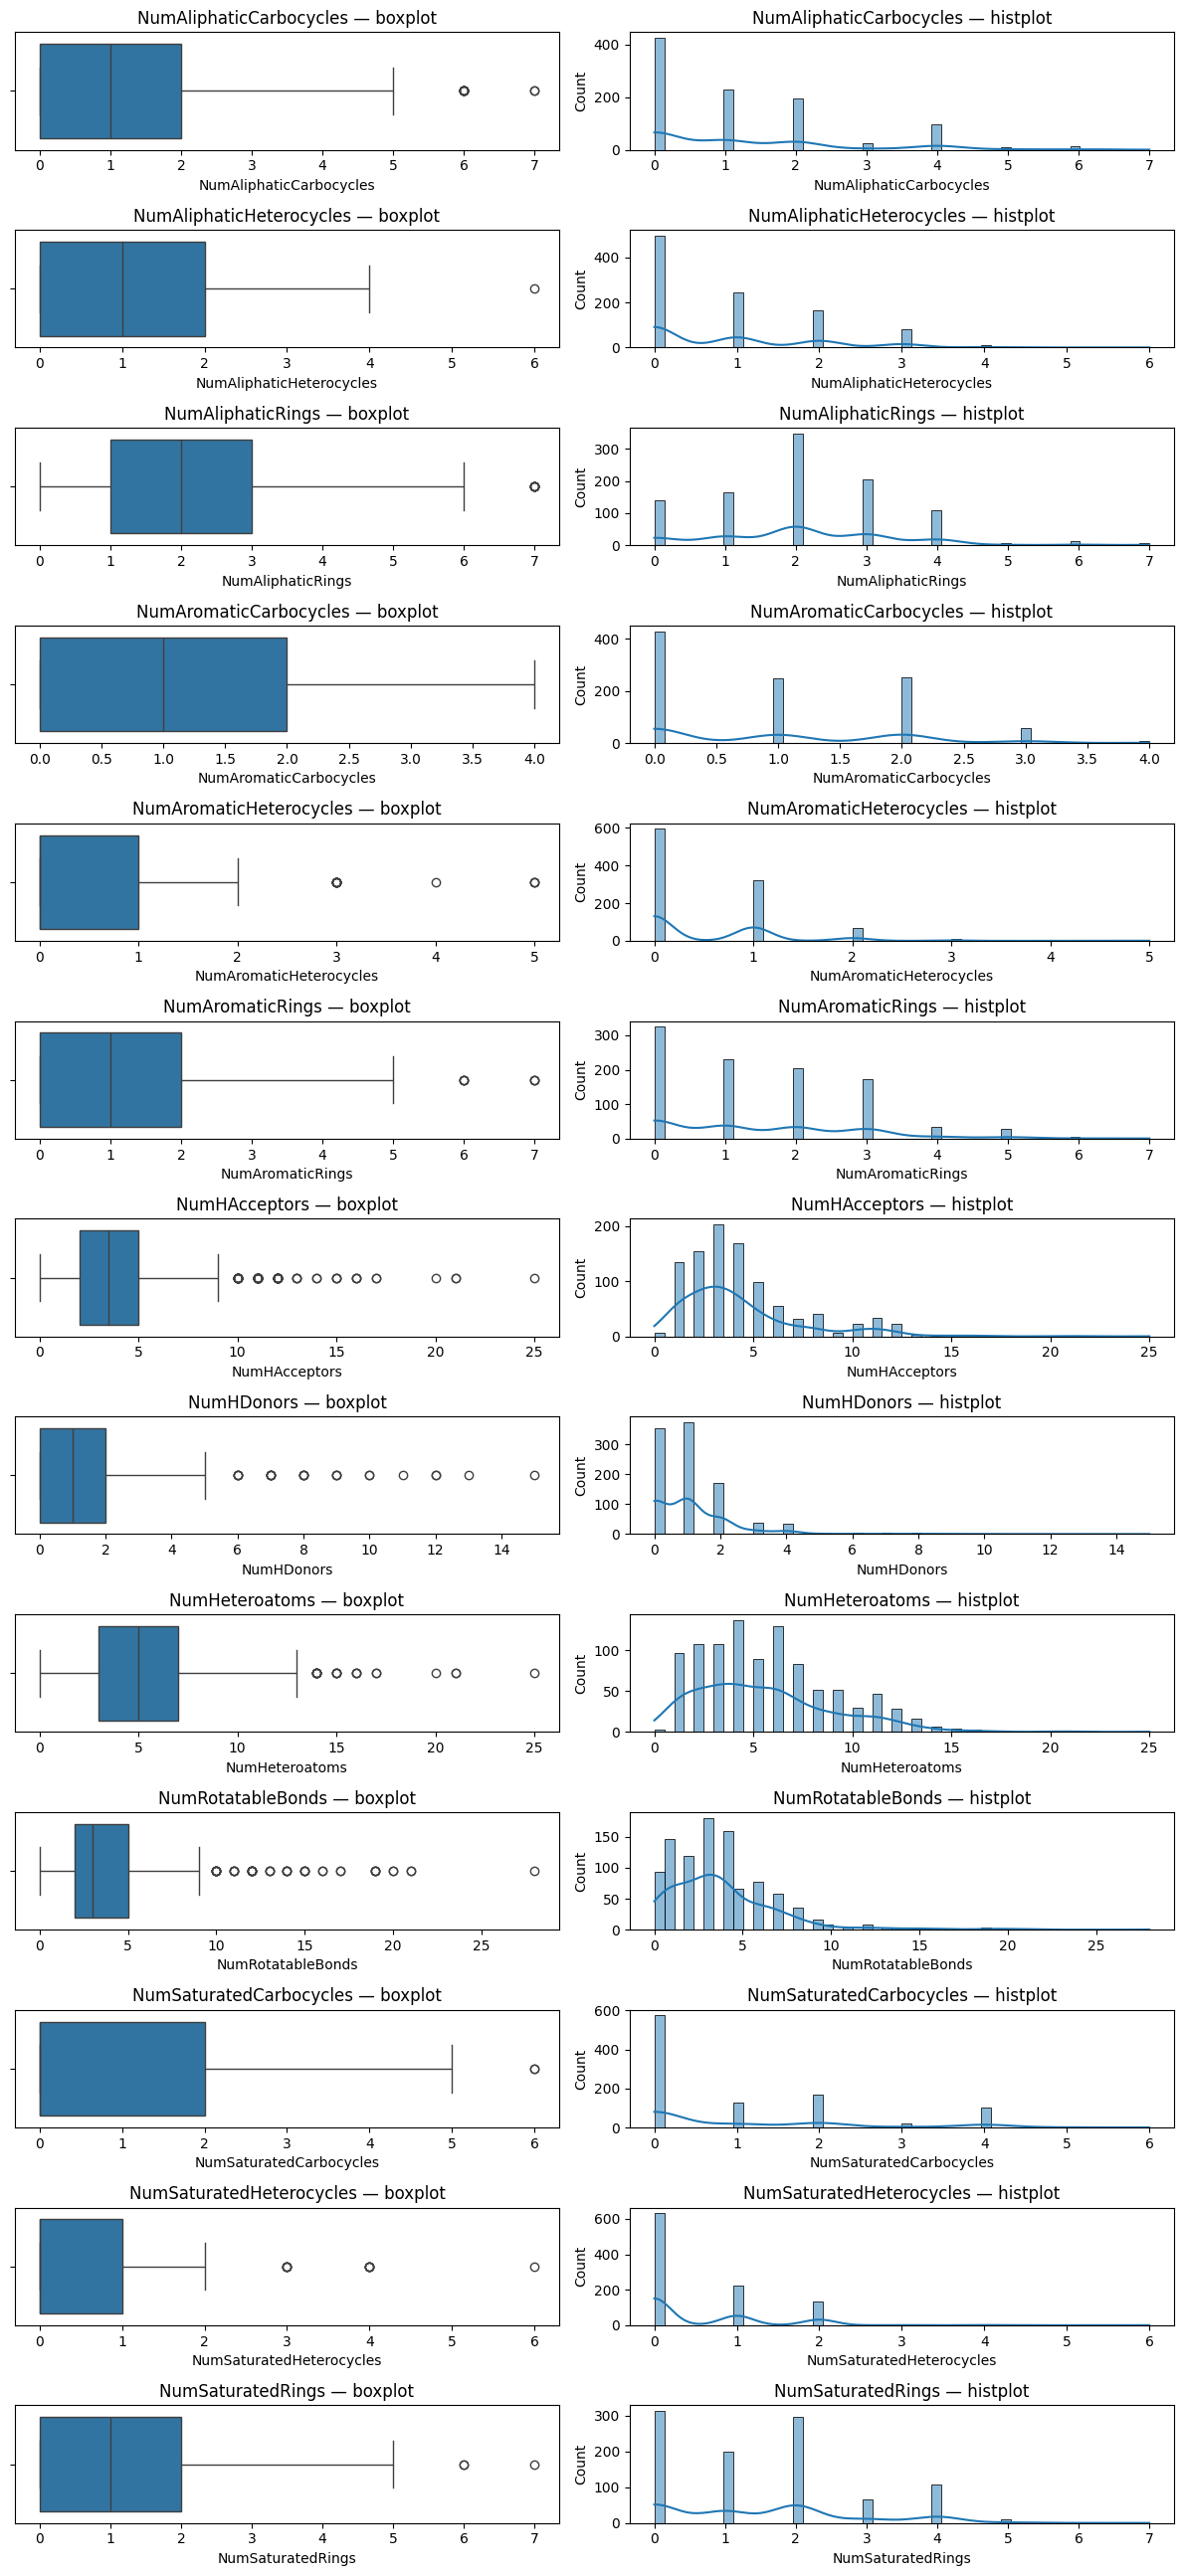


Группа: mixed


,Feature,Mean,Median,Std,Skewness,Num of Outliers
6,Ipc,4.846227e+10,113860.524554,1.257854e+12,0.038528,218
7,LabuteASA,1.467887e+02,132.552475,5.258405e+01,0.270732,54
3,BalabanJ,1.850401e+00,1.842162,4.518231e-01,0.018236,39
4,BertzCT,7.542048e+02,660.294941,4.365444e+02,0.215121,37
8,TPSA,6.122582e+01,49.690000,4.569876e+01,0.252432,22
5,HallKierAlpha,-1.892859e+00,-1.560000,1.383574e+00,0.240579,2
1,SPS,2.953985e+01,29.374328,1.272656e+01,0.013006,0
0,qed,5.811792e-01,0.635772,2.120814e-01,0.257417,0
2,AvgIpc,2.816918e+00,2.810855,4.328667e-01,0.014007,0
9,FractionCSP3,5.435482e-01,0.555556,3.104814e-01,0.038673,0


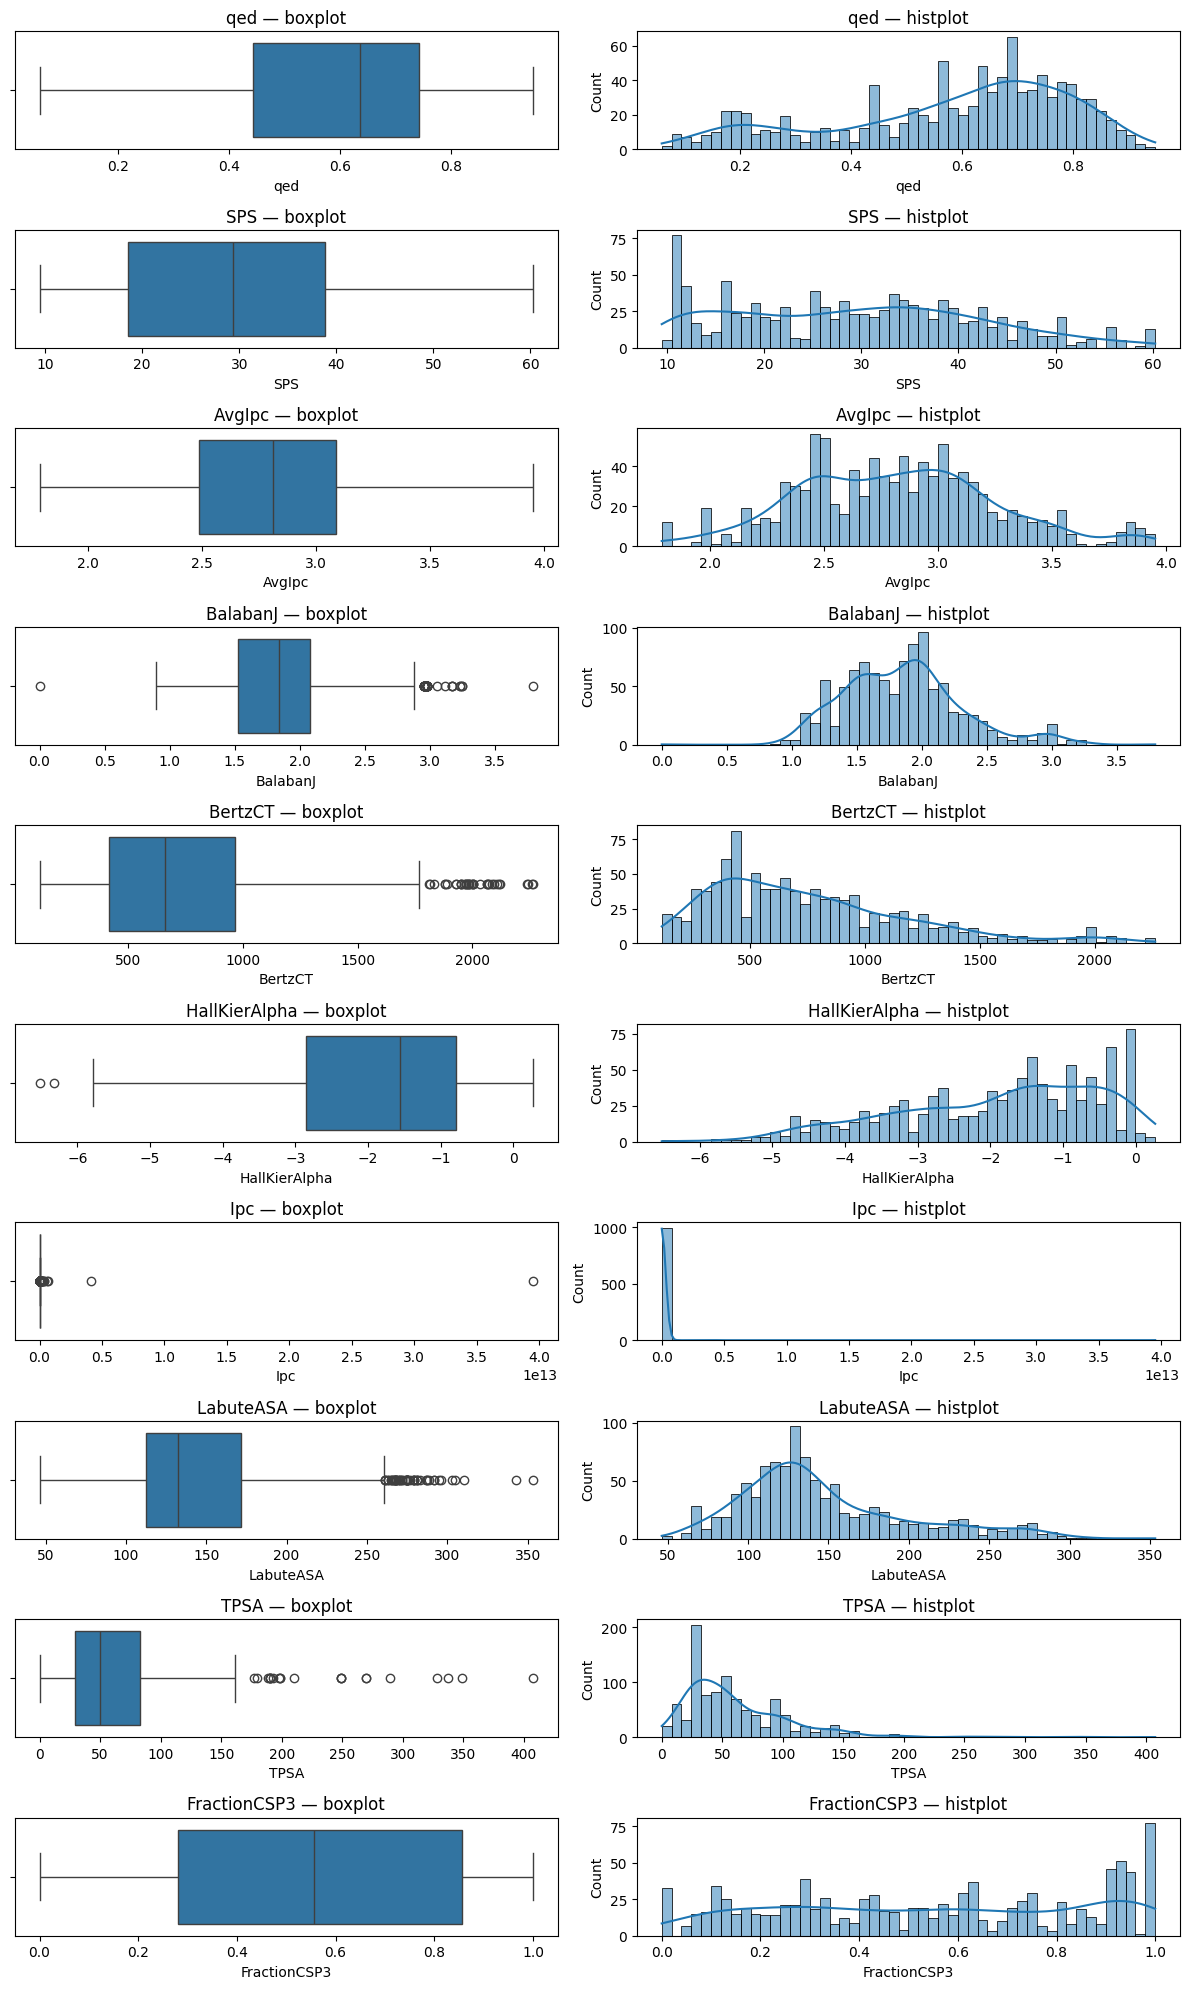

In [66]:
# Группы кроме fragments
selected_groups = [g for g in feature_groups if g != 'fragments']

# Анализ по каждой группе отдельно
for group in selected_groups:
    print(f"\nГруппа: {group}")
    features = feature_groups[group]
    summary = []

    for col in features:
        series = data[col].dropna()
        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = series[(series < lower) | (series > upper)]
        
        summary.append({
            'Feature': col,
            'Mean': series.mean(),
            'Median': series.median(),
            'Std': series.std(),
            'Skewness': abs(series.mean() - series.median()) / series.std() if series.std() != 0 else 0,
            'Num of Outliers': len(outliers)
        })

    summary_df = pd.DataFrame(summary).sort_values(by='Num of Outliers', ascending=False)
    display(summary_df)

    # Boxplots и histplot
    plt.figure(figsize=(12, len(features) * 2))
    for i, col in enumerate(features):
        plt.subplot(len(features), 2, 2 * i + 1)
        sns.boxplot(x=data[col])
        plt.title(f"{col} — boxplot")

        plt.subplot(len(features), 2, 2 * i + 2)
        sns.histplot(data[col], kde=True, bins=50)
        plt.title(f"{col} — histplot")

    plt.tight_layout()
    plt.show()


##### Посмотрим статистики признаков внутри группы fragments

In [67]:
# Статистики по этим признакам
fragment_stats = data[fragments_group].describe().T

fragment_stats.head(60)

,count,mean,std,min,25%,50%,75%,max
fr_Al_COO,998.0,0.056112,0.230254,0.0,0.0,0.0,0.0,1.0
fr_Al_OH,998.0,0.404810,1.041976,0.0,0.0,0.0,0.0,12.0
fr_Al_OH_noTert,998.0,0.311623,0.997532,0.0,0.0,0.0,0.0,12.0
fr_ArN,998.0,0.015030,0.129711,0.0,0.0,0.0,0.0,2.0
fr_Ar_COO,998.0,0.001002,0.031654,0.0,0.0,0.0,0.0,1.0
fr_Ar_N,998.0,0.580160,1.239231,0.0,0.0,0.0,1.0,12.0
fr_Ar_NH,998.0,0.036072,0.186563,0.0,0.0,0.0,0.0,1.0
fr_Ar_OH,998.0,0.190381,0.767852,0.0,0.0,0.0,0.0,8.0
fr_COO,998.0,0.057114,0.232177,0.0,0.0,0.0,0.0,1.0
fr_COO2,998.0,0.057114,0.232177,0.0,0.0,0.0,0.0,1.0


In [68]:
fragment_stats.tail(25)

,count,mean,std,min,25%,50%,75%,max
fr_nitro_arom_nonortho,998.0,0.011022,0.104458,0.0,0.0,0.0,0.0,1.0
fr_nitroso,998.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
fr_oxazole,998.0,0.004008,0.063214,0.0,0.0,0.0,0.0,1.0
fr_oxime,998.0,0.009018,0.104650,0.0,0.0,0.0,0.0,2.0
fr_para_hydroxylation,998.0,0.181363,0.482568,0.0,0.0,0.0,0.0,4.0
fr_phenol,998.0,0.178357,0.727902,0.0,0.0,0.0,0.0,8.0
fr_phenol_noOrthoHbond,998.0,0.178357,0.727902,0.0,0.0,0.0,0.0,8.0
fr_phos_acid,998.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
fr_phos_ester,998.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
fr_piperdine,998.0,0.065130,0.270158,0.0,0.0,0.0,0.0,2.0


Группа признаков fragments  — это бинарные или целочисленные индикаторы наличия/количества определённых химических фрагментов или функциональных групп в молекуле. Оставим их, как есть.

In [69]:
# Найдем и удалим признаки, где все значения равны нулю
zero_columns = data.columns[(data == 0).all()].tolist()
data = data.drop(columns=zero_columns)
print("Признаки, где все значения равны нулю:")
for i in range(0, len(zero_columns), 7):
    print(", ".join(zero_columns[i:i+7]))


Признаки, где все значения равны нулю:
NumRadicalElectrons, SMR_VSA8, SlogP_VSA9, fr_N_O, fr_SH, fr_azide, fr_barbitur
fr_benzodiazepine, fr_diazo, fr_dihydropyridine, fr_isocyan, fr_isothiocyan, fr_lactam, fr_nitroso
fr_phos_acid, fr_phos_ester, fr_prisulfonamd, fr_thiocyan


In [70]:

data.shape

(998, 196)

#### Заметим
- MolWt — Молекулярная масса
- ExactMolWt — Точная молекулярная масса
- HeavyAtomMolWt — Молекулярная масса без водорода

In [71]:
# Сделаем новый признак HydrogenMass, MolWt удалим
data['HydrogenMass'] = data['MolWt'] - data['HeavyAtomMolWt']
data = data.drop(columns=['MolWt', 'HeavyAtomMolWt'])

In [72]:
# Удалим технический столбец
columns_to_drop = [
    'Unnamed: 0'
]
data = data.drop(columns=[col for col in columns_to_drop if col in data.columns])


In [73]:
data.shape

(998, 194)

#### Посмотрим выбросы и распределения целевых переменных

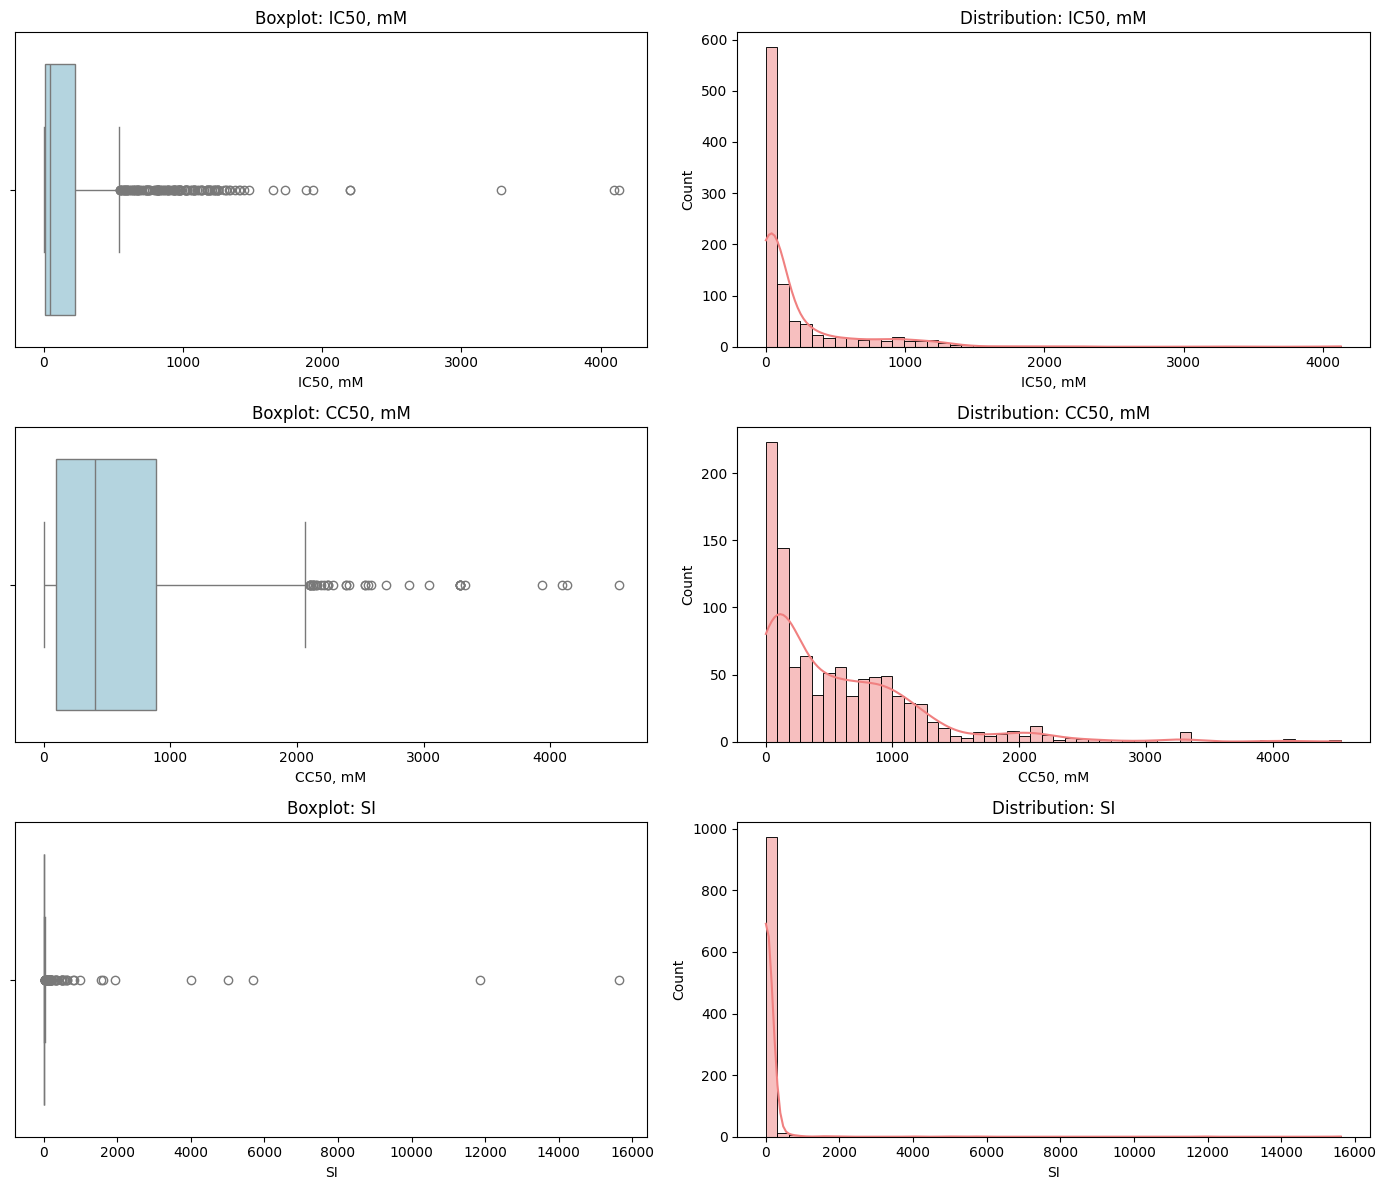

In [74]:
# Целевые переменные
targets = data[['IC50, mM', 'CC50, mM', 'SI']]

# Построение графиков
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for i, target in enumerate(targets):
    # Boxplot для выбросов
    sns.boxplot(x=data[target], ax=axes[i, 0], color='lightblue')
    axes[i, 0].set_title(f'Boxplot: {target}')
    
    # Гистограмма + распределение
    sns.histplot(data[target], kde=True, ax=axes[i, 1], bins=50, color='lightcoral')
    axes[i, 1].set_title(f'Distribution: {target}')

plt.tight_layout()
plt.show()

#### Поймем суть целевых переменных
IC50 (μM или mM) — "Полумаксимальная ингибирующая концентрация"

Назначение:
- Показывает концентрацию вещества, при которой подавляется 50% активности вируса/мишени. Это один из главных показателей эффективности препарата.

Практический смысл:
- Чем ниже IC50, тем сильнее соединение подавляет цель.
- Хорошие кандидаты обычно имеют низкие значения IC50
- менее 0.01 очень высокая активность
- более 100	почти неактивное вещество
- Если IC50 даже > 10 mM, это уже часто достаточно, чтобы отбросить соединение.

CC50 (μM или mM) — "Полумаксимальная цитотоксическая концентрация"

Назначение:
- Показывает концентрацию, при которой 50% здоровых клеток погибают. Это метрика токсичности соединения.

Практический смысл:
- Чем выше CC50, тем менее токсично вещество.
- Желательно, чтобы CC50 было намного выше IC50.
- менее 1 высокая токсичность
- более 100 нетоксично
- CC50 > 1000 mM в реальных биотестах практически не встречаются.

ввиду ограничений растворимости, стоимости реагентов, физиологической неприменимости.

SI (Selectivity Index) — "Индекс избирательности"

Формула: SI=CC50/IC50
 
Назначение:
- Характеризует избирательность действия — насколько хорошо соединение подавляет вирус по сравнению с повреждением здоровых клеток.

Практический смысл:
- Чем выше SI, тем безопаснее и предпочтительнее соединение.
- SI > 10 очень ибирательное, считается очень хорошим показателем.
- SI < 1 очень опасно или неэффективно

Идеальный кандидат: низкий IC50, высокий CC50, высокий SI

На графиках IC50 и СС50 мы видим множество выбросов, которые выходят за пределы практических значений.

#### Избавимся от выбросов

In [75]:
# Список целевых переменных
target_cols = ['SI', 'IC50, mM', 'CC50, mM']



# Удаление выбросов по каждой переменной
for col in target_cols:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]


print(f"Осталось строк после фильтрации: {data.shape[0]}")
data.shape

Осталось строк после фильтрации: 734


(734, 194)

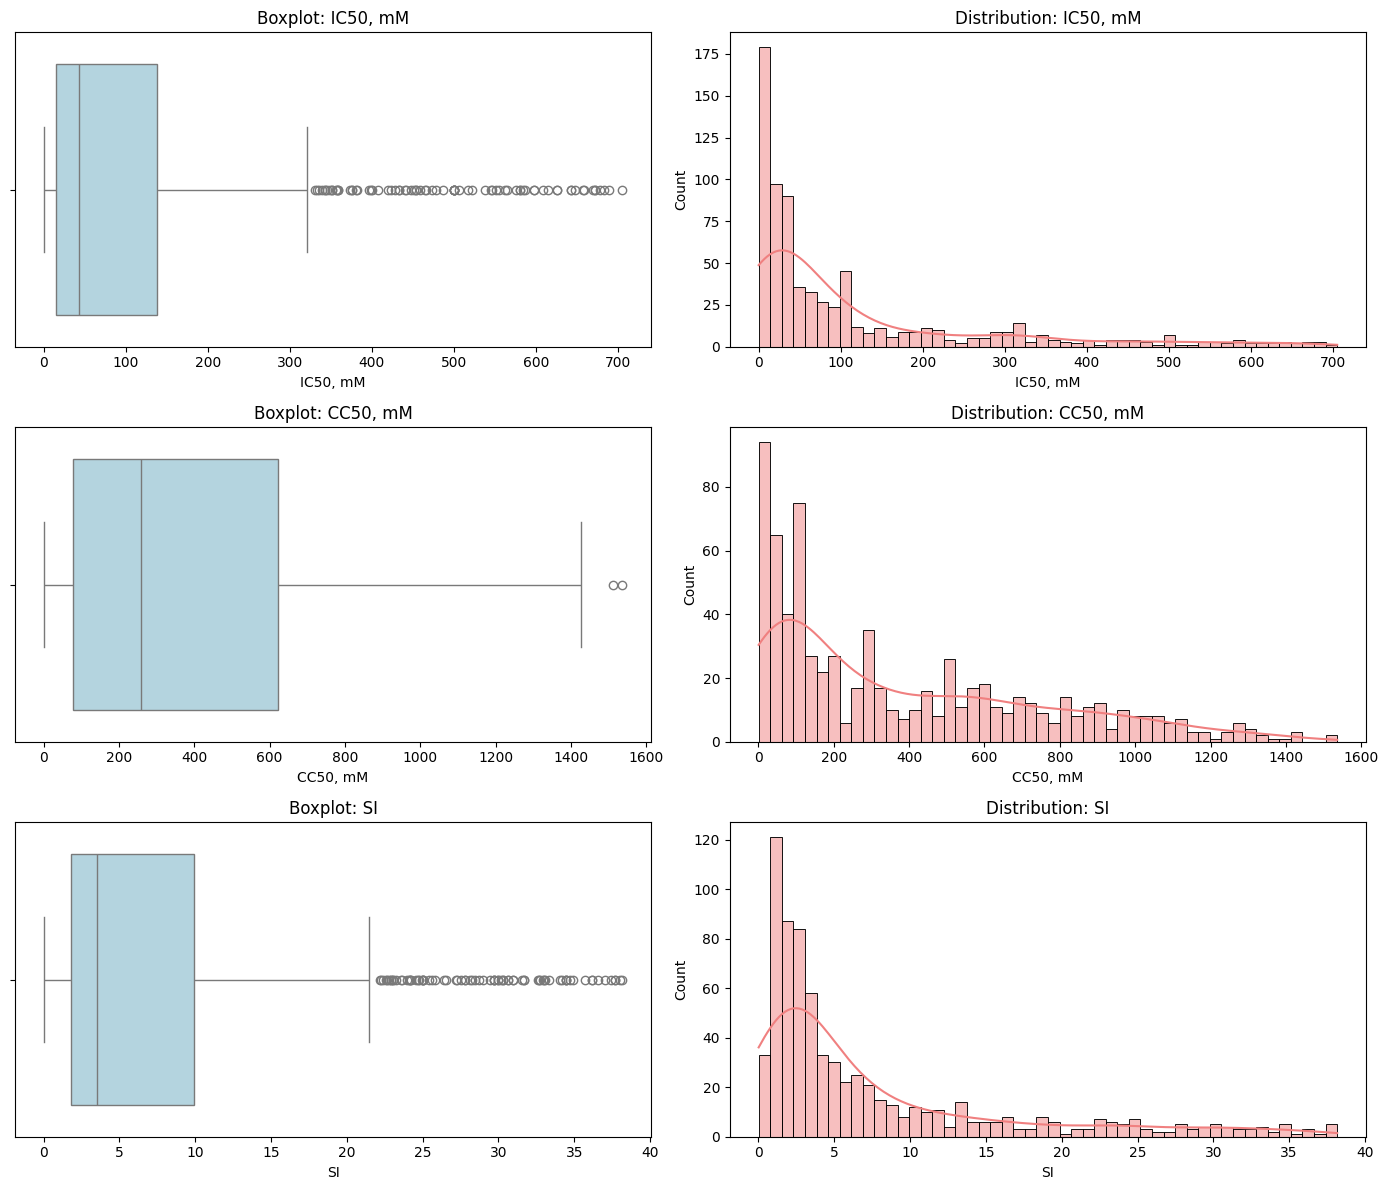

In [76]:
# Целевые переменные
targets = data[['IC50, mM', 'CC50, mM', 'SI']]

# Построение графиков
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for i, target in enumerate(targets):
    # Boxplot для выбросов
    sns.boxplot(x=data[target], ax=axes[i, 0], color='lightblue')
    axes[i, 0].set_title(f'Boxplot: {target}')
    
    # Гистограмма + распределение
    sns.histplot(data[target], kde=True, ax=axes[i, 1], bins=50, color='lightcoral')
    axes[i, 1].set_title(f'Distribution: {target}')

plt.tight_layout()
plt.show()

In [77]:
# Посчитаем количество соединений в датасете, которые могут быть лекарствами.
count = data[(data['IC50, mM'] < 100) & (data['CC50, mM'] < 1000)].shape[0]
print(f"Количество строк: {count}")

Количество строк: 485


 #### Посмотрим статистики после удаления выбросов

In [78]:
# Целевые переменные
target = ['IC50, mM', 'CC50, mM', 'SI']

# Описательная статистика
target_stats = data[target].describe().T
target_stats['median'] = data[target].median()

print(target_stats[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'median']])


          count        mean         std       min        25%         50%  \
IC50, mM  734.0  115.896009  156.219852  0.108830  15.099820   43.049903   
CC50, mM  734.0  384.109715  367.306455  0.700808  79.059629  258.410909   
SI        734.0    7.674797    8.947304  0.011489   1.787829    3.545013   

                 75%          max      median  
IC50, mM  138.147153   705.293226   43.049903  
CC50, mM  623.450022  1536.043255  258.410909  
SI          9.893714    38.168094    3.545013  


##### Проанализируем корреляции

In [79]:
# Функция нанахождения пар признаков с высокой корреляцией 
def show_corr(df, threshold=0.95, top_only=True):
    # Матрица корреляций
    corr_matrix = df.corr().abs()
    # Удалим дубликаты (нижний треугольник)
    if top_only:
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    else:
        upper = corr_matrix
    # Отфильтруем по порогу
    result = (
        upper.stack()
        .reset_index()
        .rename(columns={'level_0': 'Feature 1', 'level_1': 'Feature 2', 0: 'Correlation'})
    )
    result = result[result['Correlation'] >= threshold].sort_values(by='Correlation', ascending=False)
    print(f"Найдено {len(result)} пар признаков с корреляцией ≥ {threshold}")
    return result

# функция удаления признаков с выс. корр. по заданному порогу
def drop_high_corr(df, threshold=0.95):
    corr_pairs = show_corr(df, threshold=threshold, top_only=True)
    # Удалим второй признак из каждой пары
    to_drop = set(corr_pairs['Feature 2'])
    print(f"Удалено {len(to_drop)} признаков с корреляцией выше {threshold}")
    print(to_drop)
    df_red = df.drop(columns=to_drop)
    return df_red

def anlow_corr(df, corr_threshold=0.1, std_threshold=0.01, unique_thresh=0.95):
    # Матрица корреляций по модулю
    corr_matrix = df.corr().abs()
    # Максимальная корреляция каждого признака с другими
    max_corrs = corr_matrix.apply(lambda x: x.drop(x.name).max(), axis=1)  
    # Признаки с низкой максимальной корреляцией
    low_corr = max_corrs[max_corrs < corr_threshold]
    # Признаки с низкой дисперсией
    stds = df.std()
    low_std = stds[stds < std_threshold]
    # Признаки, где одно значение преобладает
    top_freq_ratio = df.apply(lambda x: x.value_counts(normalize=True).values[0] if x.nunique() > 1 else 1)
    low_unique = top_freq_ratio[top_freq_ratio > unique_thresh]
    # Объединяем в итоговый DataFrame
    result = pd.DataFrame(index=low_corr.index)
    result['low_corr'] = True
    result['low_std'] = result.index.isin(low_std.index)
    result['low_unique'] = result.index.isin(low_unique.index)
    result['max_corr'] = max_corrs[result.index]
    result['std'] = stds[result.index]
    result['top_freq_ratio'] = top_freq_ratio.reindex(result.index).fillna(0)
    print(f"Найдено {len(result)} признаков с max корреляцией < {corr_threshold}")
    return result

In [80]:
# Посмотрим на признаки с высокой корреляцией
df = show_corr(data, threshold=0.98)
df.head(60)

Найдено 34 пар признаков с корреляцией ≥ 0.98


,Feature 1,Feature 2,Correlation
570,MaxAbsEStateIndex,MaxEStateIndex,1.000000
18216,fr_phenol,fr_phenol_noOrthoHbond,1.000000
15997,fr_Al_COO,fr_COO2,1.000000
16445,fr_COO,fr_COO2,1.000000
15056,NumAromaticCarbocycles,fr_benzene,1.000000
15996,fr_Al_COO,fr_COO,1.000000
16333,fr_Ar_NH,fr_Nhpyrrole,1.000000
5687,Chi1,HeavyAtomCount,0.998814
5207,Chi0,HeavyAtomCount,0.996228
1883,NumValenceElectrons,Chi0,0.994528


In [81]:
# Сохранение датафрейма в файл
data.to_csv('edata.csv', index=False)

In [82]:
# Удалим признаки с высокой корреляцией
data = drop_high_corr(data, threshold=0.98)

Найдено 34 пар признаков с корреляцией ≥ 0.98
Удалено 18 признаков с корреляцией выше 0.98
{'Chi1v', 'fr_COO', 'Chi0v', 'HeavyAtomCount', 'fr_phenol_noOrthoHbond', 'Chi1n', 'MolMR', 'fr_COO2', 'fr_benzene', 'NumHDonors', 'fr_Nhpyrrole', 'LabuteASA', 'NumValenceElectrons', 'Kappa1', 'Chi1', 'Chi0', 'fr_phenol', 'MaxEStateIndex'}


In [83]:
# Сохранение датафрейма в файл
data.to_csv('edata_corr.csv', index=False)